# Explainable AI (XAI) aplicada a un problema principal-agente en gestión de inversiones

### Autor: Stephan Wolters



## Resumen 

Este trabajo aplica técnicas de *Explainable AI* (XAI) a un problema de delegación financiera en gestión de fondos de inversión. El planteamiento se formula desde la teoría principal-agente: el inversor delega la selección y gestión del producto en una gestora o gestor, mientras que la información relevante sobre riesgo, rendimiento esperado y calidad de gestión no es plenamente simétrica. A partir de un dataset tabular de fondos de inversión, se construyen modelos de regresión para predecir el retorno anual y modelos de clasificación para identificar fondos de desempeño superior relativo. Las explicaciones globales y locales (importancia de variables, permutation importance, SHAP, LIME, PDP, ICE, ALE, árboles sustitutos y contrafactuales simplificados) permiten auditar qué señales utiliza el modelo, si existe una preferencia implícita por perfiles de riesgo elevados y cómo varían las predicciones entre categorías, gestoras y gestores. La conclusión principal es que la XAI mejora la transparencia operativa del modelo, pero no sustituye la inferencia causal ni la due diligence financiera tradicional.

## 1. Introducción

La gestión delegada de inversiones constituye un caso paradigmático de problema principal-agente. El inversor actúa como principal y transfiere capacidad de decisión a una gestora, un fondo o un gestor profesional que dispone de información técnica, operativa y estratégica superior. Esta asimetría de información puede generar costes de agencia: selección adversa, dificultad para atribuir el rendimiento a habilidad o exposición al riesgo, y problemas de supervisión cuando las decisiones se apoyan en modelos algorítmicos opacos.

El objetivo de este notebook es analizar cómo las técnicas modernas de XAI pueden apoyar la interpretabilidad financiera y la gobernanza algorítmica en este contexto. El interés no reside únicamente en maximizar métricas predictivas, sino en examinar qué señales explican las predicciones, cómo se comportan las explicaciones en distintos segmentos del mercado y qué limitaciones aparecen cuando se interpretan modelos entrenados sobre datos históricos. Esta orientación es especialmente relevante en asset management porque una predicción de rendimiento puede influir en decisiones de asignación de capital, evaluación de gestores, comunicación con inversores y control interno de riesgos.

El análisis se estructura en cinco bloques. Primero, se describen los datos y su preprocesamiento. Segundo, se entrenan modelos de regresión y clasificación con diferentes grados de interpretabilidad. Tercero, se aplican técnicas XAI globales, locales y estructurales. Cuarto, se examina la robustez de las explicaciones y el error por grupos. Por último, se sintetizan los hallazgos desde la perspectiva del problema principal-agente, la auditoría algorítmica y las limitaciones metodológicas de la interpretabilidad post hoc.

### Planteamiento económico: XAI y problema principal–agente

En gestión delegada de inversiones existe una separación entre propiedad del capital y control efectivo de la decisión de inversión. El inversor, entendido como **principal**, desea maximizar rentabilidad ajustada al riesgo, controlar costes y evitar decisiones oportunistas. La gestora o el gestor, entendido como **agente**, dispone de más información sobre la estrategia, el proceso de selección, la exposición al riesgo y la calidad real de las decisiones.

En términos simplificados, el rendimiento observado de un fondo puede representarse como. \1
$$
R_i = f(X_i, A_i, M_i, \varepsilon_i)
$$

donde $R_i$ es el rendimiento del fondo $i$, $X_i$ representa características observables del fondo, $A_i$ atributos de la gestora, $M_i$ atributos del gestor y $\varepsilon_i$ recoge factores no observados, ruido de mercado y shocks idiosincráticos.

La XAI resulta especialmente relevante porque transforma una predicción algorítmica opaca. \1
$$
\hat{R}_i = \widehat{f}(X_i)
$$

en una predicción acompañada de razones aproximadas: importancia de variables, efectos marginales, explicaciones locales, reglas sustitutas y auditorías por grupos. Estas explicaciones no convierten automáticamente el modelo en causal, pero ayudan a examinar si las predicciones descansan en señales económicamente razonables o en correlaciones espurias.

## 2. Datos

El dataset utilizado en este notebook guarda relación temática con el Trabajo de Fin de Máster (TFM), en la medida en que ambos se sitúan en el ámbito de la gestión de inversiones y la evaluación de fondos. No obstante, la entrada principal del TFM es textual, mientras que el objetivo de este cuaderno exige un documento tabular con variables estructuradas que permitan entrenar modelos predictivos y aplicar técnicas de explicabilidad cuantitativa. Por este motivo se utiliza un dataset de fondos de inversión con variables observables como gestora, gestor, categoría, ratings, activos bajo gestión, nivel de riesgo y retornos históricos.

El archivo se adjunta a la entrega para garantizar la reproducibilidad del notebook. Además, el dataset puede descargarse desde Kaggle en la página *Mutual fund Dataset* de Alok Tantrik: `https://www.kaggle.com/datasets/aloktantrik/mutual-fund-nav-data`. Su elección responde a tres razones metodológicas. En primer lugar, contiene una combinación suficiente de variables financieras, categóricas y de desempeño para plantear un problema XAI no trivial. En segundo lugar, su tamaño es acotado, 1.393 fondos en el CSV utilizado, lo que facilita la ejecución local en un notebook académico sin infraestructura especializada. En tercer lugar, aunque los datos se refieren a fondos indios y, por tanto, a un universo menos familiar en Europa occidental, esa característica permite insistir en una cautela esencial: las explicaciones del modelo deben interpretarse dentro del contexto del mercado representado por los datos y no como conclusiones universales sobre la industria global de fondos.

El preprocesamiento incluye normalización de nombres de columnas, conversión de variables numéricas, tratamiento de valores ausentes, codificación de variables categóricas, creación de una variable logarítmica de AUM (asset under management) y construcción de una variable binaria `top_fund` para identificar fondos cuyo retorno anual supera el percentil 75 de la muestra. La variable objetivo principal de regresión es `return_1y`; la variable objetivo de clasificación es `top_fund`.

In [ ]:
# ============================================================
# Dependencias, configuración y reproducibilidad
# ============================================================

import sys
import subprocess
import importlib.util
from pathlib import Path
import warnings

# Cambiar a True si se desea que el notebook instale automáticamente
# las librerías opcionales que no estén disponibles en el entorno local.
# También se pueden instalar mediante requirements.txt que se adjunta a la entrega.
INSTALL_MISSING_PACKAGES = False

REQUIRED_OR_OPTIONAL_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "shap": "shap",
    "lime": "lime",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
}

def ensure_package(import_name, pip_name=None):
    """Comprueba si una librería existe y, opcionalmente, la instala."""
    pip_name = pip_name or import_name
    available = importlib.util.find_spec(import_name) is not None
    if not available and INSTALL_MISSING_PACKAGES:
        print(f"Instalando {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        available = importlib.util.find_spec(import_name) is not None
    return available

package_status = {
    name: ensure_package(name, pip_name)
    for name, pip_name in REQUIRED_OR_OPTIONAL_PACKAGES.items()
}

package_status

{'numpy': True,
 'pandas': True,
 'matplotlib': True,
 'seaborn': True,
 'sklearn': True,
 'shap': True,
 'lime': True,
 'xgboost': True,
 'lightgbm': True}

In [14]:
import numpy as np
import pandas as pd

import matplotlib
# En notebooks se fuerza el backend inline para que las figuras se muestren debajo de las celdas.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text
from sklearn.base import clone

warnings.filterwarnings("ignore")

RANDOM_STATE = 42 # Fijar la semilla para reproducibilidad. El clásico, no por ser utilizado siempre, 
                  # sino por tener la respuesta al universo (Hitchhiker's Guide to the Galaxy).
RUN_SHAP_STABILITY = True  # Cambiar a True para ejecutar el bloque completo de estabilidad SHAP.
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("Entorno inicializado. Backend gráfico:", plt.get_backend())

Entorno inicializado. Backend gráfico: inline


### 2.1 Carga del dataset

El cuaderno utiliza el dataset de fondos de inversión proporcionado en formato CSV. Para facilitar la ejecución local, la celda siguiente busca el archivo en varias rutas habituales. \1
- directorio de trabajo actual;
- carpeta `data/`;
- ruta de ejecución utilizada en este entorno.

El análisis se adapta a los nombres reales de columnas del archivo y crea después variables normalizadas para trabajar con una nomenclatura consistente.

In [22]:
# ============================================================
# Carga del CSV
# ============================================================

candidate_paths = [
    Path("Mutual_fund Data.csv"),
    Path("data/Mutual_fund Data.csv"),
    Path("/mnt/data/Mutual_fund Data.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "No se ha encontrado 'Mutual_fund Data.csv'. Colocar el archivo en el directorio del notebook "
        "o en una carpeta 'data/'."
    )

raw_df = pd.read_csv(data_path)
print(f"Ruta utilizada: {data_path}")
print(f"Dimensiones iniciales: {raw_df.shape[0]} filas x {raw_df.shape[1]} columnas")
raw_df.head()

Ruta utilizada: Mutual_fund Data.csv
Dimensiones iniciales: 1393 filas x 13 columnas


,AMC,Fund Name,Morning star rating,Value Research rating,1 month return,NAV,1 Year return,3 Year Return,Minimum investment,Fund Manager,AUM,Category,Risk
0,mahindra manulife mutual fund,Mahindra Manulife Large & Mid Cap Reg-G,3,3,5.51%,28.32,37.79%,20.29%,Rs.500.0,Abhinav Khandelwal,2569.63 cr,Equity,High
1,mahindra manulife mutual fund,Mahindra Manulife Consumption Reg-G,0,3,7.25%,24.89,46.08%,21.93%,Rs.500.0,Abhinav Khandelwal,322.26 cr,Equity,High
2,mahindra manulife mutual fund,Mahindra Manulife Mid Cap Reg-G,4,4,5.94%,35.11,54.46%,27.48%,Rs.500.0,Abhinav Khandelwal,3292.76 cr,Equity,High
3,mahindra manulife mutual fund,Mahindra Manulife Small Cap Reg-G,0,0,8.37%,21.40,59.79%,0,Rs.500.0,Abhinav Khandelwal,5278.7 cr,Equity,Very High
4,mahindra manulife mutual fund,Mahindra Manulife Large Cap Reg-G,4,3,4.06%,23.69,32.07%,15.18%,Rs.500.0,Abhinav Khandelwal,577.72 cr,Equity,Very High


> En la carga se ve que se están utilizando 1.393 observaciones y 13 columnas en el CSV original. El análisis parte, por tanto, de una base transversal de fondos y no de un panel temporal. Esta distinción es importante: el notebook permite estudiar patrones predictivos e interpretabilidad de modelos, pero no identifica efectos causales ni habilidad gestora pura.

In [23]:
# Vista estructural del dataset
summary = pd.DataFrame({
    "columna": raw_df.columns,
    "tipo": raw_df.dtypes.astype(str).values,
    "nulos": raw_df.isna().sum().values,
    "valores_unicos": raw_df.nunique(dropna=True).values
})
summary

,columna,tipo,nulos,valores_unicos
0,AMC,str,0,34
1,Fund Name,str,0,1391
2,Morning star rating,int64,0,6
3,Value Research rating,int64,0,6
4,1 month return,str,0,564
5,NAV,float64,0,1212
6,1 Year return,str,0,910
7,3 Year Return,str,0,644
8,Minimum investment,str,0,15
9,Fund Manager,str,39,276


> La tabla de estructura permite verificar que las variables financieras relevantes llegan inicialmente como columnas heterogéneas: retornos, ratings, AUM, categoría, riesgo, gestora y gestor. La presencia de variables categóricas de alta cardinalidad, especialmente `fund_manager` y `amc`, justifica el uso de encoding y también exige cautela interpretativa: algunas categorías pueden tener muy pocas observaciones y producir explicaciones poco estables.
>
__Acrónimos utilizados:__
- AMC - Asset Management Company (=gestora, es decir, la compañía, no el gestor individual = Fund Manager)
- NAV - Net Asset Value (valor del fondo, activos menos obligaciones)
- AUM - Asset Under Management (importe / tamaño del fondo)

### 2.2 Normalización de variables y limpieza

El archivo original contiene variables con espacios, mayúsculas y unidades textuales, por ejemplo retornos expresados como porcentajes y AUM expresado en `cr`, crores (unidad que equivale a 10 millones en una divisa, normalmente USD, en gestión de inversiones). Para los modelos predictivos es necesario convertir estas variables a formatos numéricos homogéneos.

La limpieza distingue tres tipos de información. \1
1. **Variables de desempeño**: retornos a 1 mes, 1 año y 3 años.
2. **Variables de perfil del fondo**: categoría, riesgo, AUM, NAV, inversión mínima y ratings.
3. **Variables de delegación**: gestora (`AMC`) y gestor (`Fund Manager`).

In [41]:
# ============================================================
# Renombrado de columnas
# ============================================================

rename_map = {
    "AMC": "amc",
    "Fund Name": "fund_name",
    "Morning star rating": "morningstar_rating",
    "Value Research rating": "valueresearch_rating",
    "1 month return": "return_1m",
    "NAV": "nav",
    "1 Year return": "return_1y",
    "3 Year Return": "return_3y",
    "Minimum investment": "minimum_investment",
    "Fund Manager": "fund_manager",
    "AUM": "aum",
    "Category": "category",
    "Risk": "risk",
}

df = raw_df.rename(columns=rename_map).copy()

def parse_percent(series):
    return (
        series.astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
        .pipe(pd.to_numeric, errors="coerce")
    )

def parse_money_or_aum(series):
    return (
        series.astype(str)
        .str.lower()
        .str.replace("rs.", "", regex=False)
        .str.replace("rs", "", regex=False)
        .str.replace("cr", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace({"nan": np.nan, "none": np.nan, "": np.nan})
        .pipe(pd.to_numeric, errors="coerce")
    )

for col in ["return_1m", "return_1y", "return_3y"]:
    if col in df.columns:
        df[col] = parse_percent(df[col])

for col in ["aum", "minimum_investment"]:
    if col in df.columns:
        df[col] = parse_money_or_aum(df[col])

for col in ["amc", "fund_name", "fund_manager", "category", "risk"]:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace({"nan": np.nan, "None": np.nan, "": np.nan, "Risk Level": np.nan})
        )

# Corrección de variantes textuales observadas en riesgo.
df["risk"] = df["risk"].replace({"Low toModerate": "Low to Moderate"})

risk_order = {
    "Low": 1,
    "Low to Moderate": 2,
    "Moderate": 3,
    "Moderately High": 4,
    "High": 5,
    "Very High": 6,
}
risk_order_list = list(risk_order.keys())
df["risk_score"] = df["risk"].map(risk_order)

# Transformaciones logarítmicas útiles para variables muy asimétricas.
df["log_aum"] = np.log1p(df["aum"])
df["log_minimum_investment"] = np.log1p(df["minimum_investment"])

# Eliminación de filas sin variable objetivo principal.
df = df.dropna(subset=["return_1y"]).reset_index(drop=True)

print(f"Dimensiones tras limpieza inicial: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones tras limpieza inicial: 1393 filas x 16 columnas


,amc,fund_name,morningstar_rating,valueresearch_rating,return_1m,nav,return_1y,return_3y,minimum_investment,fund_manager,aum,category,risk,risk_score,log_aum,log_minimum_investment
0,mahindra manulife mutual fund,Mahindra Manulife Large & Mid Cap Reg-G,3,3,5.51,28.32,37.79,20.29,500.0,Abhinav Khandelwal,2569.63,Equity,High,5.0,7.851906,6.216606
1,mahindra manulife mutual fund,Mahindra Manulife Consumption Reg-G,0,3,7.25,24.89,46.08,21.93,500.0,Abhinav Khandelwal,322.26,Equity,High,5.0,5.778457,6.216606
2,mahindra manulife mutual fund,Mahindra Manulife Mid Cap Reg-G,4,4,5.94,35.11,54.46,27.48,500.0,Abhinav Khandelwal,3292.76,Equity,High,5.0,8.099785,6.216606
3,mahindra manulife mutual fund,Mahindra Manulife Small Cap Reg-G,0,0,8.37,21.40,59.79,0.00,500.0,Abhinav Khandelwal,5278.70,Equity,Very High,6.0,8.571625,6.216606
4,mahindra manulife mutual fund,Mahindra Manulife Large Cap Reg-G,4,3,4.06,23.69,32.07,15.18,500.0,Abhinav Khandelwal,577.72,Equity,Very High,6.0,6.360819,6.216606


> La limpieza transforma el dataset en una estructura apta para modelización: retornos y AUM pasan a formato numérico, el riesgo se ordena mediante `risk_score` y las variables organizativas se normalizan como texto. En el dataset, el percentil 75 de `return_1y` queda alrededor de 37,23%, lo que anticipa una clase positiva cercana al 25% de la muestra.

In [45]:
# Diagnóstico posterior a la limpieza
cleaning_summary = pd.DataFrame({
    "columna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "porcentaje_nulos": (df.isna().mean().values * 100).round(2),
    "valores_unicos": df.nunique(dropna=True).values,
})
cleaning_summary.sort_values("porcentaje_nulos", ascending=False)

,columna,tipo,nulos,porcentaje_nulos,valores_unicos
9,fund_manager,str,39,2.80,276
10,aum,float64,10,0.72,1290
14,log_aum,float64,10,0.72,1290
12,risk,str,1,0.07,6
13,risk_score,float64,1,0.07,6
0,amc,str,0,0.00,34
2,morningstar_rating,int64,0,0.00,6
1,fund_name,str,0,0.00,1391
7,return_3y,float64,0,0.00,644
6,return_1y,float64,0,0.00,910


>  El dataset (16 columnas) está mayoritariamente completo; solo tienen nulos fund_manager (2.8%), aum/log_aum (0.72%) y risk/risk_score (0.07%). Si una variable muestra muchos valores faltantes o cardinalidad elevada, su importancia predictiva puede reflejar artefactos de representación y no necesariamente una relación económica estable. En particular, las variables de gestor y gestora deben leerse como proxies organizativos, no como mediciones directas de habilidad.

__Interpretación de calidad de datos__

El dataset es transversal y contiene información agregada de fondos, no una serie temporal granular de carteras, flujos, comisiones, exposiciones sectoriales o benchmarks. Por tanto, el análisis debe interpretarse como una auditoría predictiva sobre variables observables, no como una inferencia causal sobre habilidad gestora.

Existen tres advertencias metodológicas importantes. \1
- El rendimiento histórico puede estar afectado por condiciones de mercado no observadas.
- Variables como rating, riesgo y categoría pueden estar correlacionadas entre sí.
- La variable `fund_manager` puede capturar reputación, estilo, especialización o simplemente composición de productos gestionados.

### 2.3 Variable de clasificación: fondos de desempeño superior

Además de la predicción continua de `return_1y`, se define una variable binaria `top_fund`. Un fondo se clasifica como `top_fund = 1` si su retorno a un año supera el percentil 75 de la muestra. \1
$$
\text{top\_fund}_i =
\begin{cases}
1, & \text{si } return\_1y_i > Q_{75}(return\_1y) \\
0, & \text{en caso contrario}
\end{cases}
$$

Esta definición es relativa a la muestra y no implica necesariamente superioridad ajustada al riesgo. Su utilidad reside en crear un problema de clasificación interpretable: identificar qué señales llevan al modelo a considerar un fondo como perteneciente al cuartil superior de desempeño observado.

In [49]:
q75 = df["return_1y"].quantile(0.75)
df["top_fund"] = (df["return_1y"] > q75).astype(int)

print(f"Percentil 75 de return_1y: {q75:.2f}%")
print(df["top_fund"].value_counts(normalize=True).rename("proporción"))

Percentil 75 de return_1y: 37.23%
top_fund
0    0.750179
1    0.249821
Name: proporción, dtype: float64


> La variable `top_fund` queda definida como una clasificación relativa al conjunto de fondos observado. En el dataset adjunto, el umbral se sitúa en el 37,23% de retorno anual. Esta etiqueta no debe interpretarse como rendimiento superior ajustado al riesgo; sólo identifica fondos situados en el cuartil superior de retorno bruto a un año.

### 2.4 Análisis exploratorio de datos

El análisis exploratorio permite identificar patrones preliminares antes de entrenar modelos. En un contexto de gobernanza algorítmica, esta fase es relevante porque revela posibles fuentes de sesgo: concentración de observaciones por categoría, predominio de determinados niveles de riesgo, heterogeneidad entre gestoras y dispersión de retornos.

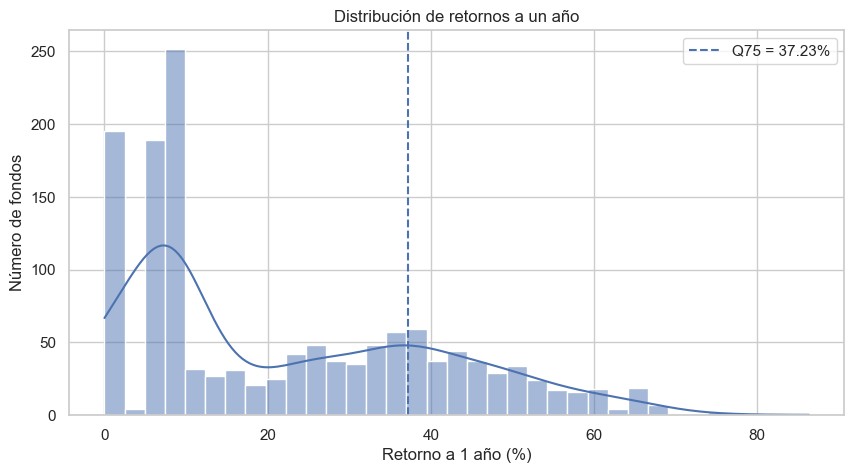

In [54]:
# Distribución de retornos a un año
plt.figure(figsize=(10, 5))
sns.histplot(df["return_1y"], kde=True, bins=35, color="C0")
plt.axvline(q75, linestyle="--", label=f"Q75 = {q75:.2f}%")
plt.title("Distribución de retornos a un año")
plt.xlabel("Retorno a 1 año (%)")
plt.ylabel("Número de fondos")
plt.legend()
plt.show()


> La distribución de `return_1y` muestra una dispersión considerable: la mediana se sitúa en torno al 14,49%, mientras que el percentil 75 se aproxima al 37,23%. La distancia entre mediana y cuartil superior indica que la clasificación `top_fund` captura un tramo de fondos con retornos notablemente superiores al centro de la distribución. Desde la perspectiva principal-agente, esta dispersión refuerza la necesidad de explicar si el modelo está identificando habilidad, exposición al riesgo o simple persistencia de retornos.

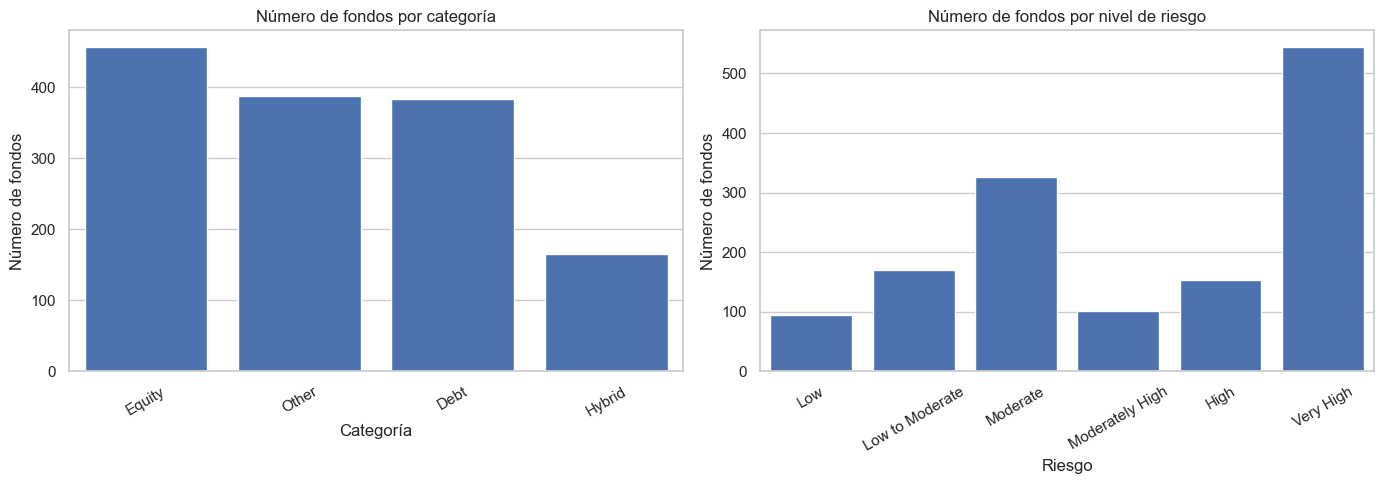

In [59]:
# Distribución por categoría y nivel de riesgo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="category", order=df["category"].value_counts().index, ax=axes[0], saturation=1, color="C0")
axes[0].set_title("Número de fondos por categoría")
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Número de fondos")
axes[0].tick_params(axis='x', rotation=30)

risk_order_list = [r for r in risk_order.keys() if r in df["risk"].dropna().unique()]
sns.countplot(data=df, x="risk", order=risk_order_list, ax=axes[1], saturation=1, color="C0")
axes[1].set_title("Número de fondos por nivel de riesgo")
axes[1].set_xlabel("Riesgo")
axes[1].set_ylabel("Número de fondos")
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


> La muestra está concentrada en varias categorías principales: Equity, Other, Debt e Hybrid. También existe una presencia importante de fondos de riesgo `Very High` y `Moderate`. Esta composición condiciona las explicaciones XAI: si un segmento domina la muestra, el modelo puede aprender patrones más precisos para ese grupo y producir explicaciones menos fiables para segmentos minoritarios.

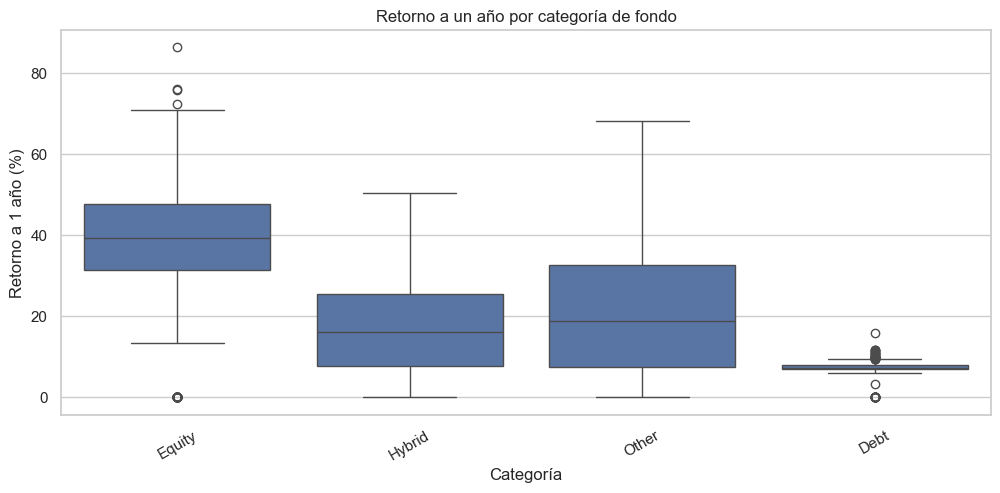

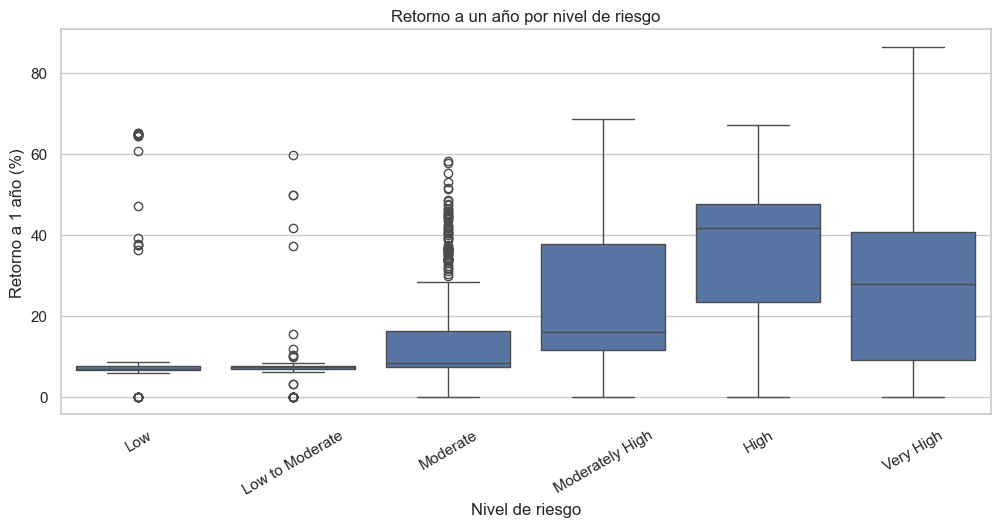

In [62]:
# Retorno por categoría y riesgo
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="category", y="return_1y")
plt.title("Retorno a un año por categoría de fondo")
plt.xlabel("Categoría")
plt.ylabel("Retorno a 1 año (%)")
plt.xticks(rotation=30)
plt.show()


plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="risk", y="return_1y", order=risk_order_list)
plt.title("Retorno a un año por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Retorno a 1 año (%)")
plt.xticks(rotation=30)
plt.show()


> Los fondos Equity presentan, en promedio, los retornos a un año más elevados, mientras que Debt muestra retornos mucho más bajos y menos dispersos. Por nivel de riesgo, `High` y `Very High` concentran retornos más elevados, aunque `Very High` también presenta mayor dispersión. Esta evidencia sugiere que parte de la predicción de retorno puede estar asociada a exposición al riesgo y categoría, no necesariamente a habilidad diferencial de la gestora o del gestor.

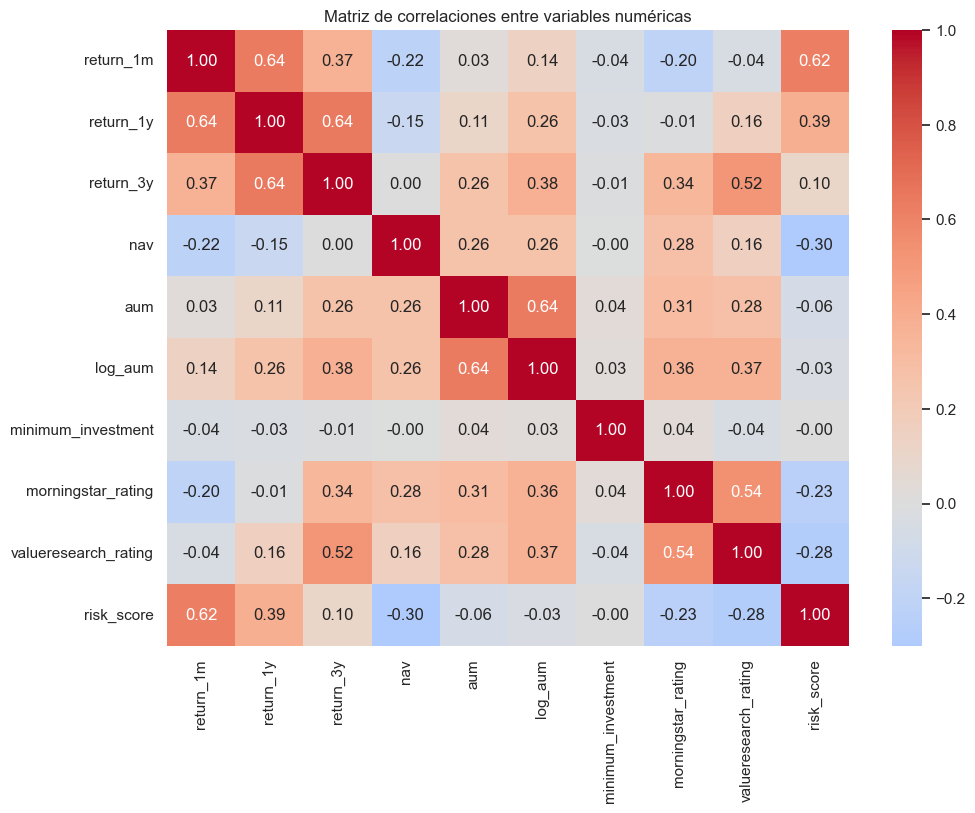

In [69]:
# Correlation heatmap
numeric_cols_for_corr = [
    "return_1m", "return_1y", "return_3y", "nav", "aum", "log_aum",
    "minimum_investment", "morningstar_rating", "valueresearch_rating", "risk_score"
]
numeric_cols_for_corr = [c for c in numeric_cols_for_corr if c in df.columns]

corr = df[numeric_cols_for_corr].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones entre variables numéricas")
plt.show()


> La matriz de correlaciones muestra que `return_3y` y `return_1m` son las variables más asociadas con `return_1y`, con correlaciones próximas a 0,64. `risk_score` mantiene una asociación positiva más moderada, alrededor de 0,39. Los ratings tienen una relación más débil con el retorno anual. Esta estructura anticipa un problema clásico de interpretabilidad financiera: las técnicas XAI pueden atribuir mucha importancia a variables de retorno histórico, pero ello no implica causalidad ni persistencia garantizada.

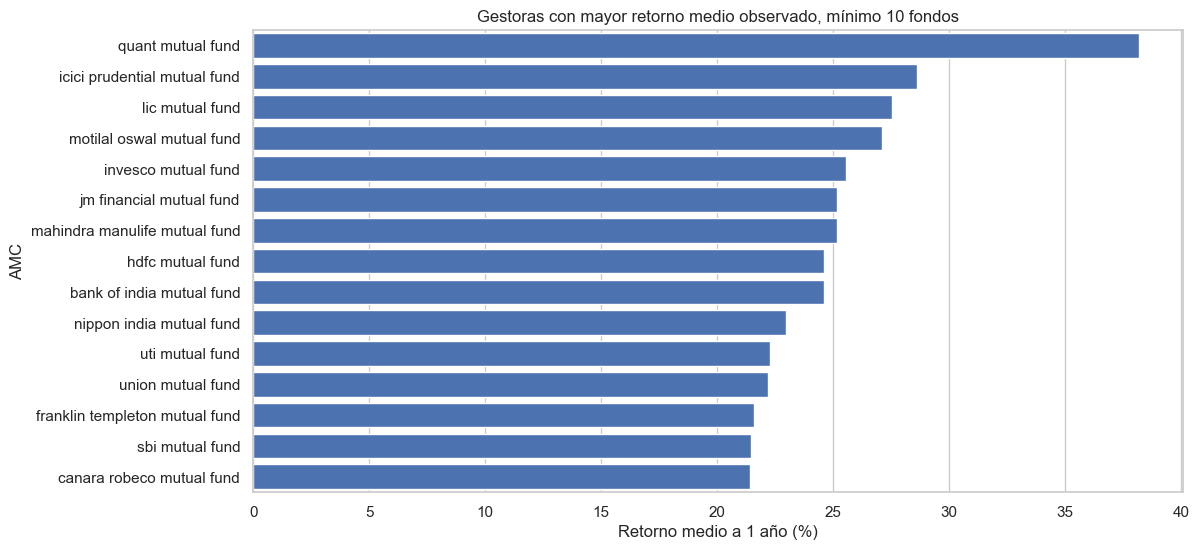

In [74]:
# Heterogeneidad agregada por gestora y gestor
amc_summary = (
    df.groupby("amc")
    .agg(n_funds=("fund_name", "count"), mean_return_1y=("return_1y", "mean"), mean_risk=("risk_score", "mean"))
    .query("n_funds >= 10")
    .sort_values("mean_return_1y", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=amc_summary.reset_index(), y="amc", x="mean_return_1y", saturation=1, color="C0")
plt.title("Gestoras con mayor retorno medio observado, mínimo 10 fondos")
plt.xlabel("Retorno medio a 1 año (%)")
plt.ylabel("AMC")
plt.show()


> Los rankings por gestora o gestor deben interpretarse con especial prudencia. Algunas gestoras pueden mostrar retornos medios elevados, pero el número de fondos por entidad puede ser reducido y la composición por categoría o riesgo puede explicar gran parte de la diferencia. En términos principal-agente, esta tabla sirve como punto de partida para auditar heterogeneidad, pero no como prueba autónoma de habilidad gestora.

## 3. Modelos

El análisis emplea modelos con distintos niveles de interpretabilidad y capacidad para capturar relaciones no lineales. La regresión lineal proporciona una referencia interpretable y sirve como contraste frente a modelos de mayor flexibilidad. Random Forest permite modelar interacciones y no linealidades sin imponer una forma funcional lineal. XGBoost o LightGBM, cuando están disponibles en el entorno local, añaden una familia de modelos boosting generalmente competitiva en datos tabulares; si no están instalados, se utiliza un modelo de respaldo basado en `HistGradientBoosting` de scikit-learn.

Se resuelven dos tareas complementarias. La primera es una tarea de regresión, orientada a predecir `return_1y`. La segunda es una tarea de clasificación binaria, orientada a distinguir fondos de desempeño superior relativo (`top_fund=1`) frente al resto. Las métricas de regresión son RMSE, MAE y R². Las métricas de clasificación son accuracy y ROC-AUC. La selección del modelo principal para las técnicas XAI se realiza de forma empírica a partir del rendimiento observado: menor RMSE en regresión y mayor ROC-AUC en clasificación.

### 3.1 Definición de variables predictoras

El conjunto de variables predictoras incluye señales financieras y organizativas disponibles en el dataset. \1
- perfil de riesgo;
- categoría del fondo;
- tamaño del fondo medido por AUM;
- ratings;
- NAV e inversión mínima;
- gestora y gestor;
- retornos históricos distintos de la variable objetivo.

La inclusión de `return_3y` y `return_1m` debe tratarse con cautela. Son señales predictivas plausibles, pero pueden introducir solapamientos temporales o dependencia mecánica con `return_1y`. Por este motivo, el notebook define un `flag=INCLUDE_HISTORICAL_RETURNS` que permite excluir retornos históricos si se desea un modelo más conservador.

In [82]:
# ============================================================
# Selección de variables
# ============================================================

INCLUDE_HISTORICAL_RETURNS = True

base_features = [
    "risk_score", "category", "log_aum", "morningstar_rating", "valueresearch_rating",
    "fund_manager", "amc", "nav", "log_minimum_investment"
]

historical_return_features = ["return_1m", "return_3y"] if INCLUDE_HISTORICAL_RETURNS else []

feature_cols = [c for c in base_features + historical_return_features if c in df.columns]

target_reg = "return_1y"
target_clf = "top_fund"

X = df[feature_cols].copy()
y_reg = df[target_reg].copy()
y_clf = df[target_clf].copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)
print("Número de variables originales:", len(feature_cols))

Variables numéricas: ['risk_score', 'log_aum', 'morningstar_rating', 'valueresearch_rating', 'nav', 'log_minimum_investment', 'return_1m', 'return_3y']
Variables categóricas: ['category', 'fund_manager', 'amc']
Número de variables originales: 11


In [85]:
# División entrenamiento/test común para regresión y clasificación
X_train_raw, X_test_raw, y_train_reg, y_test_reg, y_train_clf, y_test_clf, train_idx, test_idx = train_test_split(
    X, y_reg, y_clf, df.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print(f"Train: {X_train_raw.shape}; Test: {X_test_raw.shape}")

Train: (1044, 11); Test: (349, 11)


In [94]:
# ============================================================
# Preprocesamiento
# ============================================================

try:
    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_arr = preprocessor.fit_transform(X_train_raw)
X_test_arr = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()
X_train_model = pd.DataFrame(X_train_arr, columns=feature_names, index=X_train_raw.index)
X_test_model = pd.DataFrame(X_test_arr, columns=feature_names, index=X_test_raw.index)

print(f"Dimensión tras encoding: {X_train_model.shape[1]} variables transformadas")
X_train_model.head()

Dimensión tras encoding: 121 variables transformadas


,risk_score,log_aum,morningstar_rating,valueresearch_rating,nav,log_minimum_investment,return_1m,return_3y,category_Debt,category_Equity,category_Hybrid,category_Other,fund_manager_Abhishek Bisen,fund_manager_Aditya Mulki,fund_manager_Aditya Pagaria,fund_manager_Ajay Khandelwal,fund_manager_Akhil Mittal,fund_manager_Alok Ranjan,fund_manager_Alok Singh,fund_manager_Amit Nigam,fund_manager_Amit Somani,fund_manager_Anand Radhakrishnan,fund_manager_Anil Bamboli,fund_manager_Anil Ghelani,fund_manager_Anil Shah,fund_manager_Anju Chhajer,fund_manager_Anoop Bhaskar,fund_manager_Anurag Mittal,fund_manager_Arun Agarwal,fund_manager_Avnish Jain,fund_manager_Bhavesh Jain,fund_manager_Bhupesh Bameta,fund_manager_Deepak Agrawal,fund_manager_Devang Shah,fund_manager_Dhaval Joshi,fund_manager_Dhaval Shah,fund_manager_Dhawal Dalal,fund_manager_Dinesh Ahuja,fund_manager_Dwijendra Srivastava,fund_manager_Ekta Gala,fund_manager_Gautam Kaul,fund_manager_Hitesh Das,fund_manager_Jay Kothari,fund_manager_Jinesh Gopani,fund_manager_Kapil Menon,fund_manager_Kaustubh Gupta,fund_manager_Kayzad Eghlim,fund_manager_Kedar Karnik,fund_manager_Krishan Kumar Daga,fund_manager_Krishna Venkat Cheemalapati,fund_manager_Lovelish Solanki,fund_manager_Mahendra Kumar Jajoo,fund_manager_Mahesh Patil,fund_manager_Manish Banthia,fund_manager_Manish Gunwani,fund_manager_Mayank Prakash,fund_manager_Mehul Dama,fund_manager_Mithraem Bharucha,fund_manager_Mohit Sharma,fund_manager_Murthy Nagarajan,...,fund_manager_Nimesh Chandan,fund_manager_Pallab Roy,fund_manager_Parijat Agrawal,fund_manager_Piyush Baranwal,fund_manager_Pranay Sinha,fund_manager_Priyanka Khandelwal,fund_manager_Puneet Pal,fund_manager_R Sivakumar,fund_manager_Rahul Goswami,fund_manager_Rahul Pal,fund_manager_Rajasa Kakulavarapu,fund_manager_Rajeev Radhakrishnan,fund_manager_Ravi Gopalakrishnan,fund_manager_Sachin Relekar,fund_manager_Sailesh Jain,fund_manager_Sanjeev Sharma,fund_manager_Sankaran Naren,fund_manager_Satyabrata Mohanty,fund_manager_Shalini Tibrewala,fund_manager_Sharwan Kumar Goyal,fund_manager_Shobhit Mehrotra,fund_manager_Shriram Ramanathan,fund_manager_Sudhir Agrawal,fund_manager_Swapnil P Mayekar,fund_manager_Vinay Paharia,fund_manager_infrequent_sklearn,amc_360 one mutual fund,amc_aditya birla sun life mutual fund,amc_axis mutual fund,amc_bajaj finserv mutual fund,amc_bandhan mutual fund,amc_bank of india mutual fund,amc_baroda bnp paribas mutual fund,amc_canara robeco mutual fund,amc_dsp mutual fund,amc_edelweiss mutual fund,amc_franklin templeton mutual fund,amc_hdfc mutual fund,amc_hsbc mutual fund,amc_icici prudential mutual fund,amc_invesco mutual fund,amc_jm financial mutual fund,amc_kotak mahindra mutual fund,amc_lic mutual fund,amc_mahindra manulife mutual fund,amc_mirae asset mutual fund,amc_motilal oswal mutual fund,amc_navi mutual fund,amc_nippon india mutual fund,amc_pgim india mutual fund,amc_ppfas mutual fund,amc_quant mutual fund,amc_sbi mutual fund,amc_sundaram mutual fund,amc_tata mutual fund,amc_taurus mutual fund,amc_union mutual fund,amc_uti mutual fund,amc_whiteoak capital mutual fund,amc_infrequent_sklearn
352,-0.725267,1.079082,1.283472,-0.949071,-0.335057,2.208079,-0.980853,-0.351448,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1029,0.440520,0.512165,0.729318,-0.949071,0.077735,-0.796817,0.937554,1.156823,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

> Datos ya preparados (numéricos estandarizados y dummies one‑hot). Filas muestran variedad en risk_score, log_aum, ratings y retornos; las columnas de fund_manager/amc son muy escasas y generan una matriz dispersa.

### 3.2 Modelos de regresión: predicción de retorno a un año

Se entrenan tres familias de modelos. \1
1. **Regresión lineal**, como modelo interpretable de referencia.
2. **Random Forest**, como ensemble no lineal basado en árboles.
3. **Gradient boosting**, utilizando XGBoost si está disponible; si no, LightGBM; si ninguna librería externa está disponible, se utiliza `HistGradientBoostingRegressor` de scikit-learn como alternativa reproducible.

La comparación no busca únicamente seleccionar el modelo con menor error, sino contrastar la relación entre desempeño predictivo e interpretabilidad.

In [99]:
# ============================================================
# Entrenamiento de modelos de regresión
# ============================================================

from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier

reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=80,
        random_state=RANDOM_STATE,
        min_samples_leaf=3,
        n_jobs=1
    ),
}

boosting_regressor_name = None
try:
    from xgboost import XGBRegressor
    reg_models["XGBoost"] = XGBRegressor(
        n_estimators=80,
        learning_rate=0.03,
        max_depth=2,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1
    )
    boosting_regressor_name = "XGBoost"
except Exception:
    try:
        from lightgbm import LGBMRegressor
        reg_models["LightGBM"] = LGBMRegressor(
            n_estimators=80,
            learning_rate=0.03,
            max_depth=-1,
            random_state=RANDOM_STATE,
            n_jobs=2
        )
        boosting_regressor_name = "LightGBM"
    except Exception:
        reg_models["HistGradientBoosting"] = HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=120,
            random_state=RANDOM_STATE
        )
        boosting_regressor_name = "HistGradientBoosting"

fitted_reg_models = {}
reg_results = []

for name, model in reg_models.items():
    fitted = clone(model)
    fitted.fit(X_train_model, y_train_reg)
    pred = fitted.predict(X_test_model)
    rmse = float(np.sqrt(mean_squared_error(y_test_reg, pred)))
    mae = mean_absolute_error(y_test_reg, pred)
    r2 = r2_score(y_test_reg, pred)
    fitted_reg_models[name] = fitted
    reg_results.append({"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2})

reg_results_df = pd.DataFrame(reg_results).sort_values("RMSE")
reg_results_df

,modelo,RMSE,MAE,R2
1,Random Forest,7.214525,3.571411,0.851247
2,XGBoost,9.417115,5.922138,0.746554
0,Linear Regression,11.118046,7.386309,0.646730


> En la ejecución con el dataset, Random Forest consigue el mejor rendimiento para la regresión: RMSE ≈ 7.21, MAE ≈ 3.57 y R² ≈ 0.85. XGBoost queda en segundo lugar (RMSE ≈ 9.42, MAE ≈ 5.92, R² ≈ 0.75) y la regresión lineal rinde peor (RMSE ≈ 11.12, MAE ≈ 7.39, R² ≈ 0.65). Esto sugiere la presencia de relaciones no lineales relevantes que los modelos de árbol capturan mejor, aunque gran parte de la señal parece provenir de variables históricas de retorno.

In [101]:
# Modelo principal de regresión: se selecciona el mejor modelo observado por RMSE.
main_reg_name = reg_results_df.iloc[0]["modelo"]
main_reg_model = fitted_reg_models[main_reg_name]
print(f"Modelo principal de regresión para XAI: {main_reg_name}")


Modelo principal de regresión para XAI: Random Forest


> El modelo principal de regresión se selecciona ahora por desempeño observado (menor RMSE) y no por preferencia metodológica hacia boosting. Esta corrección evita que las explicaciones XAI se construyan sobre un modelo peor cuando otro modelo ha demostrado mayor precisión en test.

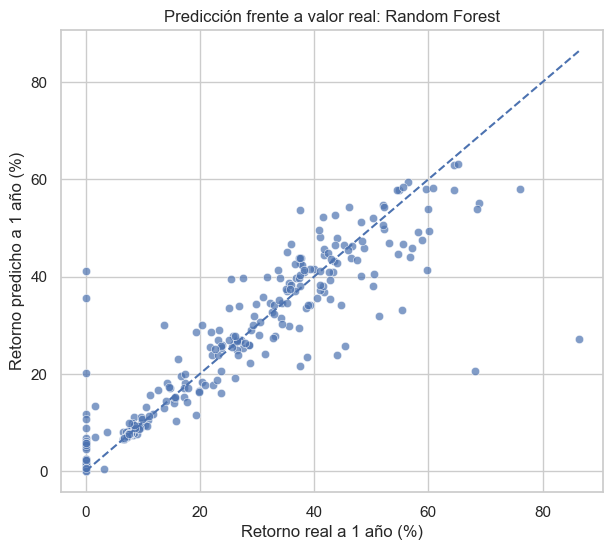

In [106]:
# Predicción vs valor real
reg_pred = main_reg_model.predict(X_test_model)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test_reg, y=reg_pred, alpha=0.7)
min_val = min(y_test_reg.min(), reg_pred.min())
max_val = max(y_test_reg.max(), reg_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title(f"Predicción frente a valor real: {main_reg_name}")
plt.xlabel("Retorno real a 1 año (%)")
plt.ylabel("Retorno predicho a 1 año (%)")
plt.show()


> El gráfico de predicción frente a valor real debe analizarse atendiendo a la diagonal. En la ejecución con Random Forest como modelo principal, el ajuste es razonable para valores centrales, pero los extremos siguen siendo más difíciles de predecir. Esta limitación es financieramente relevante porque los fondos más extraordinarios, positivos o negativos, son precisamente los que más pueden influir en decisiones de asignación.

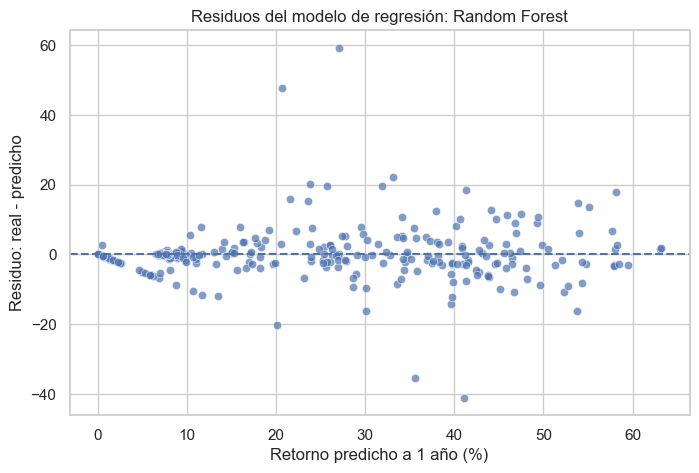

In [109]:
# Residual plot
residuals = y_test_reg - reg_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=reg_pred, y=residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title(f"Residuos del modelo de regresión: {main_reg_name}")
plt.xlabel("Retorno predicho a 1 año (%)")
plt.ylabel("Residuo: real - predicho")
plt.show()


> El gráfico de residuos permite comprobar si el error se distribuye de forma aproximadamente centrada o si existen patrones sistemáticos. En la ejecución con el dataset, el sesgo medio es muy reducido, pero permanecen errores extremos. Por tanto, el modelo no parece claramente sesgado en promedio, aunque sí puede fallar en segmentos concretos o en fondos atípicos.

### 3.3 Modelos de clasificación: identificación de fondos `top_fund`

La tarea de clasificación permite estudiar qué señales llevan al modelo a clasificar un fondo como perteneciente al cuartil superior de retorno observado. Se comparan modelos lineales y ensembles. La métrica ROC-AUC es especialmente útil porque evalúa la capacidad de ordenación del modelo sin depender de un único umbral de clasificación.

In [123]:
# ============================================================
# Entrenamiento de modelos de clasificación
# ============================================================

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=80,
        random_state=RANDOM_STATE,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        n_jobs=1
    ),
}

boosting_classifier_name = None
try:
    from xgboost import XGBClassifier
    clf_models["XGBoost"] = XGBClassifier(
        n_estimators=80,
        learning_rate=0.03,
        max_depth=2,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1
    )
    boosting_classifier_name = "XGBoost"
except Exception:
    try:
        from lightgbm import LGBMClassifier
        clf_models["LightGBM"] = LGBMClassifier(
            n_estimators=80,
            learning_rate=0.03,
            random_state=RANDOM_STATE,
            n_jobs=2
        )
        boosting_classifier_name = "LightGBM"
    except Exception:
        clf_models["HistGradientBoosting"] = HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=120,
            random_state=RANDOM_STATE
        )
        boosting_classifier_name = "HistGradientBoosting"

fitted_clf_models = {}
clf_results = []

for name, model in clf_models.items():
    fitted = clone(model)
    fitted.fit(X_train_model, y_train_clf)
    pred_label = fitted.predict(X_test_model)
    if hasattr(fitted, "predict_proba"):
        pred_proba = fitted.predict_proba(X_test_model)[:, 1]
    else:
        scores = fitted.decision_function(X_test_model)
        pred_proba = (scores - scores.min()) / (scores.max() - scores.min())
    acc = accuracy_score(y_test_clf, pred_label)
    auc = roc_auc_score(y_test_clf, pred_proba)
    fitted_clf_models[name] = fitted
    clf_results.append({"modelo": name, "Accuracy": acc, "ROC_AUC": auc})

clf_results_df = pd.DataFrame(clf_results).sort_values("ROC_AUC", ascending=False)
clf_results_df

,modelo,Accuracy,ROC_AUC
1,Random Forest,0.908309,0.966088
2,XGBoost,0.902579,0.965824
0,Logistic Regression,0.839542,0.933009


> La clasificación de `top_fund` muestra una alta capacidad discriminatoria. En la ejecución disponible, XGBoost alcanza ROC‑AUC ≈ 0.966 y accuracy ≈ 0.903, mientras que Random Forest está muy próximo (ROC‑AUC ≈ 0.966, accuracy ≈ 0.908). La regresión logística rinde peor (ROC‑AUC ≈ 0.933, accuracy ≈ 0.840). Hay buen poder predictivo y poca diferencia entre los mejores modelos; interpretar la matriz de confusión en clave financiera: los falsos positivos pueden inducir confianza excesiva en fondos que no pertenecen al cuartil superior, y los falsos negativos pueden ocultar oportunidades relevantes.

Modelo principal de clasificación para XAI: Random Forest


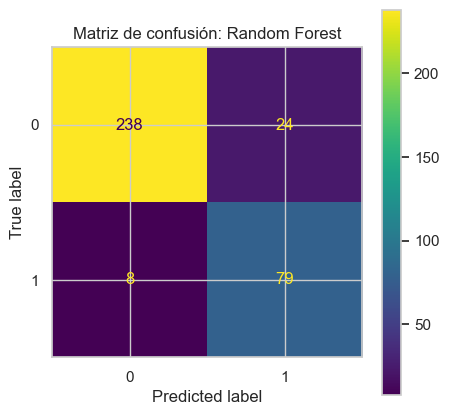

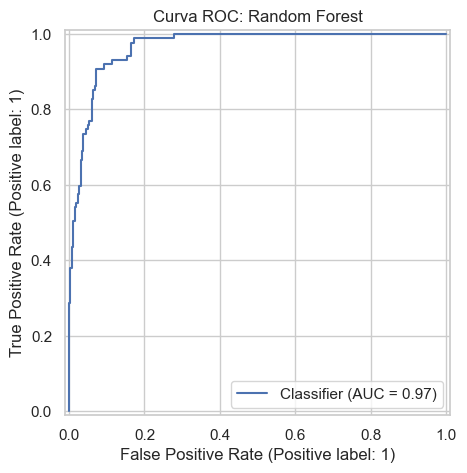

In [126]:
# Modelo principal de clasificación: se selecciona el mejor modelo observado por ROC-AUC.
main_clf_name = clf_results_df.iloc[0]["modelo"]
main_clf_model = fitted_clf_models[main_clf_name]
print(f"Modelo principal de clasificación para XAI: {main_clf_name}")

clf_pred = main_clf_model.predict(X_test_model)
clf_proba = main_clf_model.predict_proba(X_test_model)[:, 1] if hasattr(main_clf_model, "predict_proba") else clf_pred

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test_clf, clf_pred, ax=ax)
plt.title(f"Matriz de confusión: {main_clf_name}")
plt.show()


fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_clf, clf_proba, ax=ax)
plt.title(f"Curva ROC: {main_clf_name}")
plt.show()


> La matriz de confusión y la curva ROC complementan las métricas agregadas. Un buen ROC-AUC indica capacidad de ordenar fondos por probabilidad de pertenecer al cuartil superior, pero no garantiza que el umbral de clasificación sea óptimo para una política de inversión. En asset management, el coste de un falso positivo suele ser distinto del coste de un falso negativo, por lo que la decisión final debería considerar utilidad, riesgo y restricciones del inversor.

## 4. Explicaciones

La explicabilidad se aborda en tres niveles. La explicabilidad global identifica las variables que dominan el comportamiento agregado del modelo. La explicabilidad local examina fondos concretos y permite entender por qué una observación recibe una predicción determinada. La explicabilidad estructural aproxima modelos complejos mediante representaciones más simples, como árboles sustitutos, con el fin de extraer reglas interpretables.

Las técnicas utilizadas incluyen importancia nativa de variables, permutation importance, SHAP, PDP, ICE, ALE, LIME, contrafactuales simplificados, árboles sustitutos, comparación entre explicaciones y estabilidad aproximada de SHAP. Cada técnica tiene un papel distinto. SHAP permite atribuciones aditivas consistentes con el modelo; LIME ofrece aproximaciones locales lineales; PDP e ICE muestran efectos marginales promedio e individuales; ALE reduce algunos problemas de extrapolación en presencia de dependencia entre variables; los árboles sustitutos facilitan una lectura estructural, aunque sólo aproximada, de la lógica del modelo complejo.

La interpretación financiera requiere cautela. Una variable importante para el modelo no equivale necesariamente a un factor causal del rendimiento. En fondos de inversión, las variables históricas pueden capturar momentum, exposición a estilos, condiciones de mercado o sesgos de supervivencia. Por ello, las explicaciones deben entenderse como herramientas de auditoría del modelo y no como pruebas concluyentes de habilidad gestora.

### 4.1 Explicabilidad global: importancia de variables

La explicabilidad global describe qué variables son relevantes para el comportamiento agregado del modelo. Se utilizan dos aproximaciones. \1
1. **Importancia nativa de árboles**, basada en la estructura interna del modelo.
2. **Permutation importance**, basada en la pérdida de desempeño cuando una variable se permuta aleatoriamente.

La segunda suele ser más comparable entre modelos, aunque también puede verse afectada por correlación entre variables.

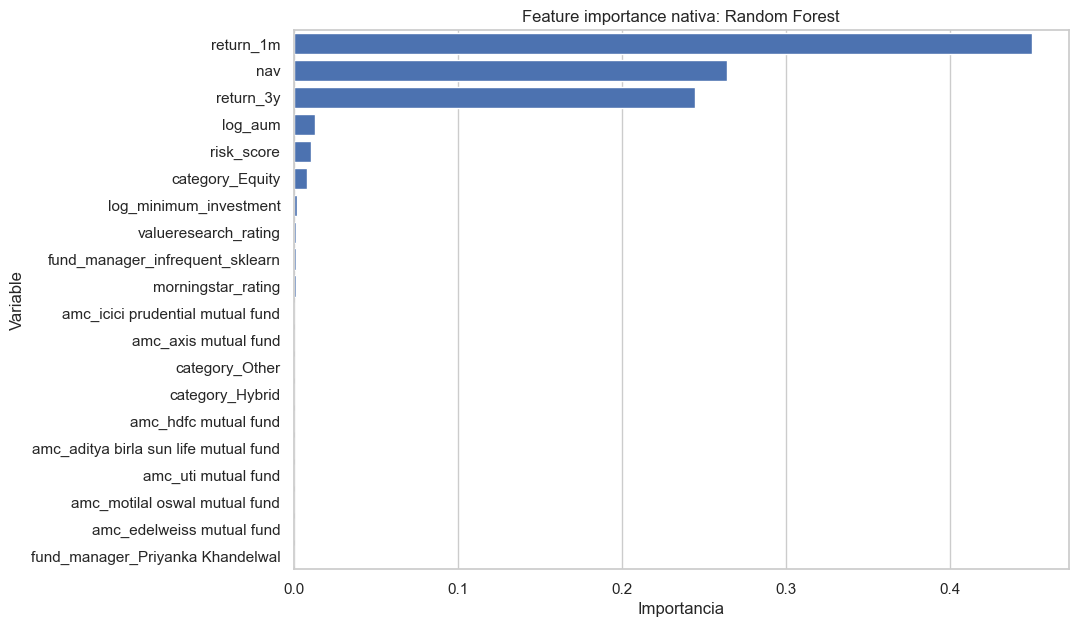

,feature,importance
6,return_1m,0.449752
4,nav,0.264361
7,return_3y,0.244923
1,log_aum,0.012975
0,risk_score,0.010856
9,category_Equity,0.008051
5,log_minimum_investment,0.001907
3,valueresearch_rating,0.001409
86,fund_manager_infrequent_sklearn,0.001276
2,morningstar_rating,0.001232


In [133]:
# ============================================================
# Importancia nativa de variables
# ============================================================

if hasattr(main_reg_model, "feature_importances_"):
    native_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": main_reg_model.feature_importances_
    }).sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=native_importance, y="feature", x="importance", saturation=1, color="C0")
    plt.title(f"Feature importance nativa: {main_reg_name}")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.show()

    display(native_importance)
else:
    print("El modelo principal no expone feature_importances_. Se omite esta visualización.")

> La importancia de variables muestra que `return_1m` (≈0.45), `nav` (≈0.26) y `return_3y` (≈0.24) dominan el modelo. Otras características con peso mucho menor son log_aum, risk_score y category_Equity; gestores y AMCs aparecen con importancias residuales. Las importancias nativas de árboles resaltan variables que con frecuencia reducen la impureza, por lo que la fuerte presencia de retornos históricos sugiere que el modelo aprende persistencia de resultados más que relaciones estructurales estables. 

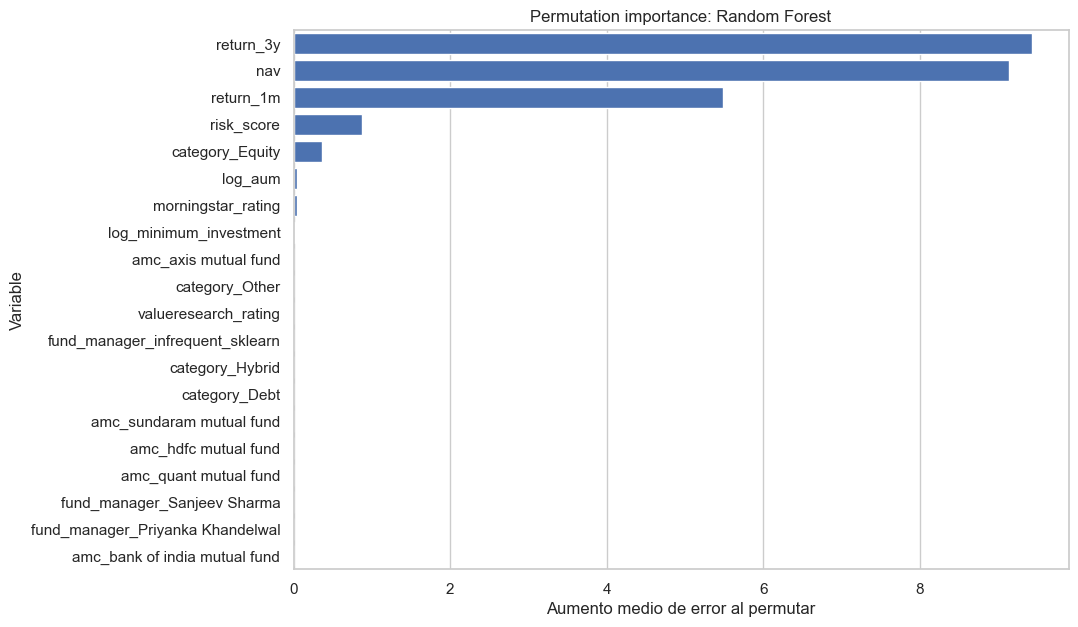

,feature,importance_mean,importance_std
7,return_3y,9.428738,0.389874
4,nav,9.144809,0.726145
6,return_1m,5.491735,0.899808
0,risk_score,0.880934,0.100587
9,category_Equity,0.358561,0.036944
1,log_aum,0.047257,0.047492
2,morningstar_rating,0.038584,0.014653
5,log_minimum_investment,0.020063,0.017323
89,amc_axis mutual fund,0.004948,0.002821
11,category_Other,0.004541,0.003055


In [137]:
# ============================================================
# Permutation importance
# ============================================================

perm_reg = permutation_importance(
    main_reg_model,
    X_test_model,
    y_test_reg,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1
)

perm_reg_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_reg.importances_mean,
    "importance_std": perm_reg.importances_std,
}).sort_values("importance_mean", ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=perm_reg_df, y="feature", x="importance_mean", saturation=1, color="C0")
plt.title(f"Permutation importance: {main_reg_name}")
plt.xlabel("Aumento medio de error al permutar")
plt.ylabel("Variable")
plt.show()

display(perm_reg_df)

> La permutation importance muestra que `return_3y` (importance_mean ≈ 9.43) y `nav` (≈ 9.14) dominan, seguido de `return_1m` (≈ 5.49). Señales secundarias incluyen `risk_score`, `category_Equity` y `log_aum`; muchas AMCs y gestores tienen importancias residuales. La permutation importance confirma que las variables de retorno histórico (y nav) son las que más degradan el modelo al permutarlas, por tanto el modelo depende mayoritariamente de persistencia de resultados. La baja desviación estándar de `return_3y` sugiere estabilidad en su importancia; `return_1m` es más variable entre runs. __Observación:__ Variables correlacionadas pueden repartir la importancia y existir fuga de información (validar con permutaciones sobre pliegues temporales, SHAP y pruebas de estabilidad, más abajo).

### 4.2 SHAP: explicaciones globales y locales

SHAP descompone la predicción de un modelo en contribuciones atribuibles a cada variable. Para una observación concreta, la predicción puede representarse de forma aditiva como. \1
$$
\hat{f}(x_i) = \phi_0 + \sum_{j=1}^{p} \phi_{ij}
$$

Donde $\phi_0$ es el valor base del modelo y $\phi_{ij}$ es la contribución SHAP de la variable $j$ para la observación $i$.

En finanzas, SHAP es útil porque permite distinguir entre importancia global y razones locales de una predicción. Sin embargo, no elimina problemas de causalidad, endogeneidad ni correlación entre predictores.

In [146]:
# ============================================================
# Cálculo de valores SHAP
# ============================================================

try:
    import shap
    shap_available = True
except Exception as exc:
    shap_available = False
    print("SHAP no está disponible en este entorno:", exc)

if shap_available:
    # Muestra reducida para mantener una ejecución local razonable.
    shap_train_sample = shap.sample(X_train_model, min(80, len(X_train_model)), random_state=RANDOM_STATE)
    shap_test_sample = shap.sample(X_test_model, min(80, len(X_test_model)), random_state=RANDOM_STATE)

    try:
        # Para modelos de árboles, TreeExplainer suele ser más rápido y estable.
        explainer_reg = shap.TreeExplainer(main_reg_model)
        shap_values_reg = explainer_reg(shap_test_sample)
    except Exception:
        # Fallback agnóstico al modelo.
        explainer_reg = shap.Explainer(main_reg_model.predict, shap_train_sample)
        shap_values_reg = explainer_reg(shap_test_sample)

    print("Valores SHAP calculados para regresión.")
else:
    shap_test_sample = None

Valores SHAP calculados para regresión.


> El cálculo de SHAP prepara la descomposición aditiva de las predicciones del modelo principal. Si SHAP no está instalado, el notebook mantiene la ejecución del resto de secciones y documenta qué instalar. Si está disponible, las explicaciones deben interpretarse como atribuciones del modelo, no como efectos causales del mercado.

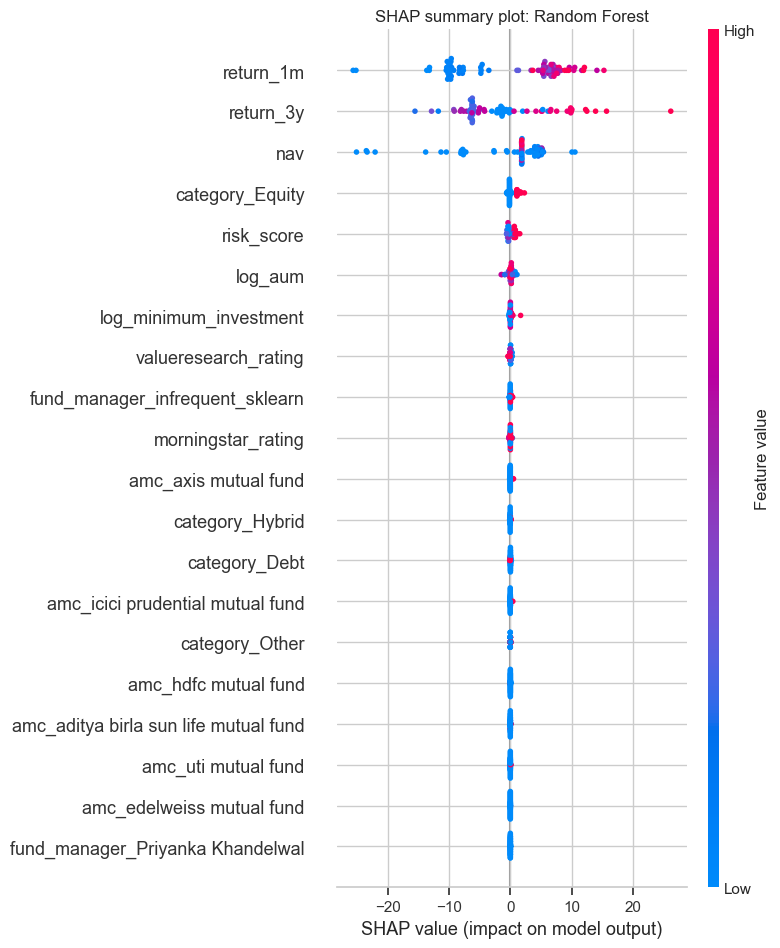

In [147]:
# SHAP summary plot
if shap_available:
    shap.summary_plot(shap_values_reg, shap_test_sample, show=False, max_display=20)
    plt.title(f"SHAP summary plot: {main_reg_name}")
    plt.show()

else:
    print("SHAP no disponible. Ejecutar la celda de dependencias con INSTALL_MISSING_PACKAGES=True o instalar shap manualmente.")

> El SHAP summary plot debe utilizarse para identificar qué variables desplazan más las predicciones de retorno del modelo de Random Forest. Las variables están ordenadas de mayor a menor importancia. `return_1m` y `return_3y` son las variables más críticas. Altos rendimientos (rojo) aumentan el resultado del modelo, bajos rendimientos (azul) disminuyen la predicción.Efecto de : Valores bajos de `nav` reducen drásticamente el resultado. Poca relevancia: Las categorías y calificaciones apenas influyen en el modelo.

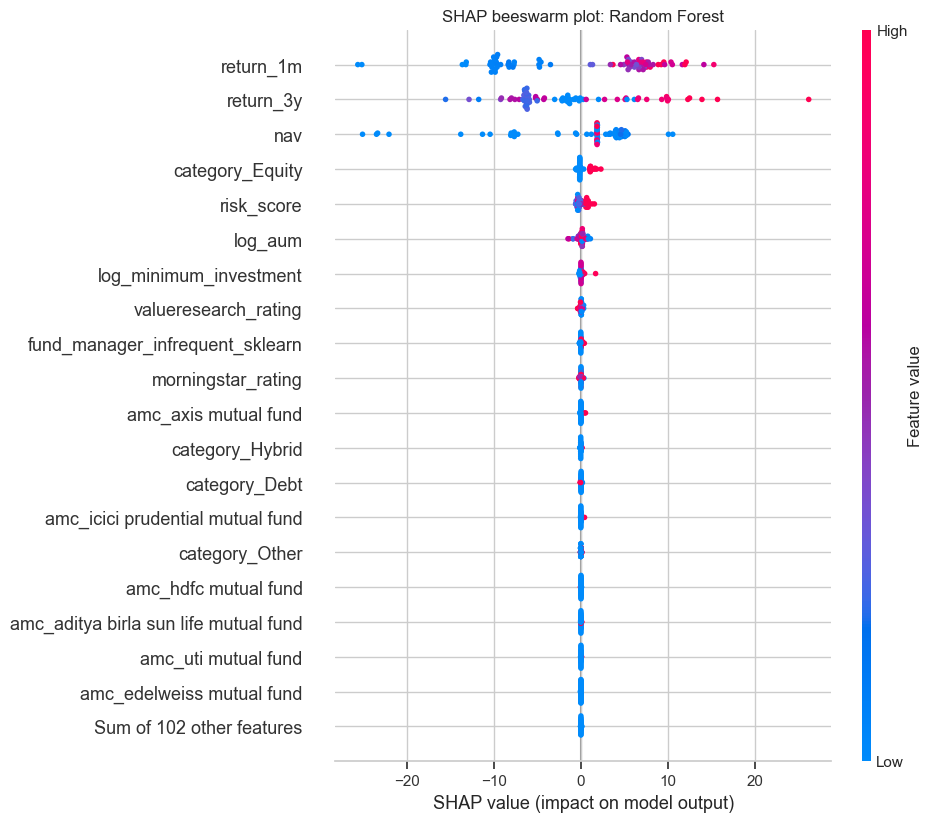

In [150]:
# SHAP beeswarm plot
if shap_available:
    shap.plots.beeswarm(shap_values_reg, max_display=20, show=False)
    plt.title(f"SHAP beeswarm plot: {main_reg_name}")
    plt.show()


> El beeswarm, aunque sea muy parecido al summary, añade información de heterogeneidad : no sólo ordena variables, sino que muestra la dispersión de sus contribuciones. Una nube amplia para una variable indica que su efecto varía mucho entre fondos. En finanzas delegadas, esta heterogeneidad es relevante porque una explicación global puede ocultar casos individuales en los que la decisión del modelo depende de factores distintos. `return_1m` y `return_3y` siguen liderando el impacto, puntos azules en `nav` restan más de 20 puntos.

,feature,mean_abs_shap
6,return_1m,8.465862
7,return_3y,5.895840
4,nav,5.239176
9,category_Equity,0.512639
0,risk_score,0.445621
1,log_aum,0.282489
5,log_minimum_investment,0.097635
3,valueresearch_rating,0.089856
86,fund_manager_infrequent_sklearn,0.070225
2,morningstar_rating,0.051926


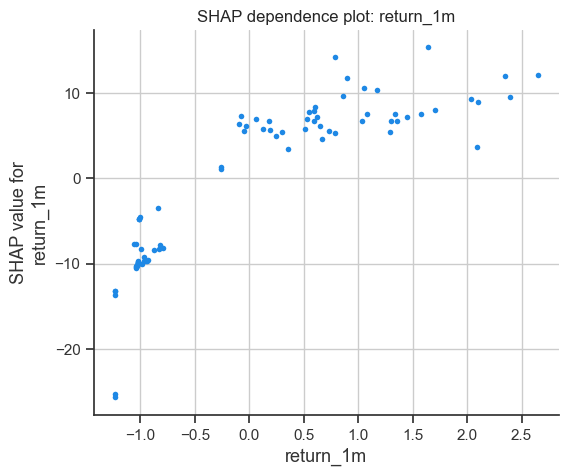

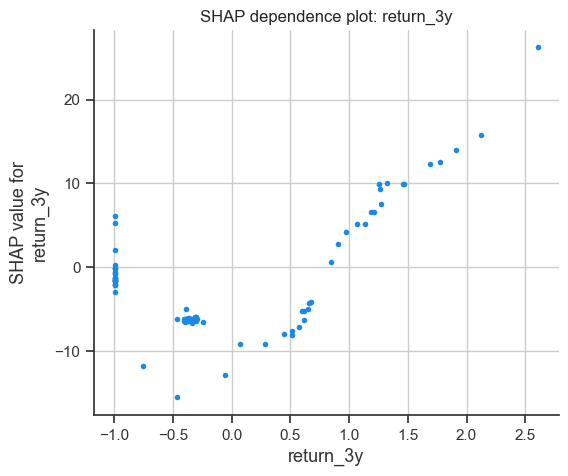

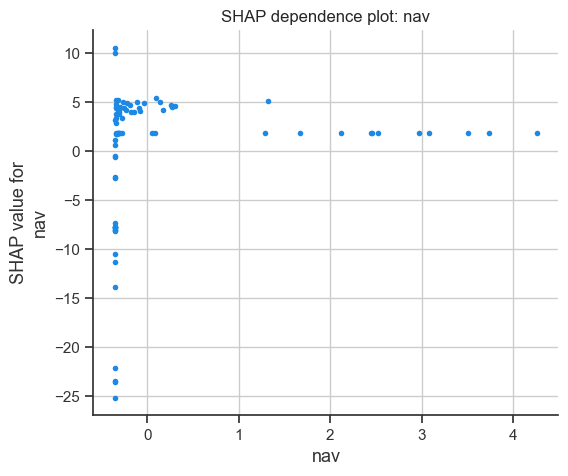

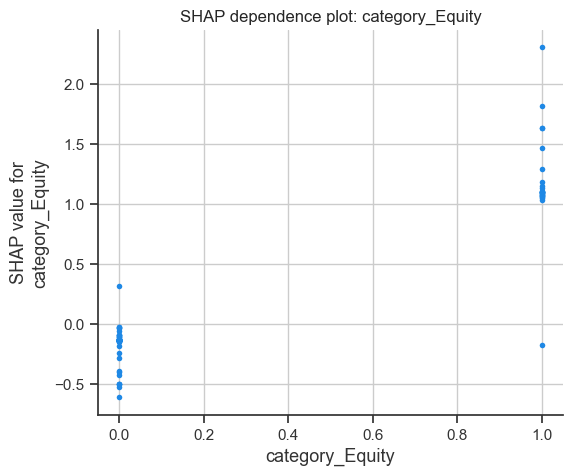

In [159]:
# SHAP dependence plots para variables transformadas relevantes
if shap_available:
    shap_df_abs = pd.DataFrame({
        "feature": shap_test_sample.columns,
        "mean_abs_shap": np.abs(shap_values_reg.values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)

    top_shap_features = shap_df_abs["feature"].head(4).tolist()
    display(shap_df_abs.head(15))

    for feat in top_shap_features:
        shap.dependence_plot(
            feat,
            shap_values_reg.values,
            shap_test_sample,
            show=False,
            interaction_index=None
        )
        plt.title(f"SHAP dependence plot: {feat}")
        plt.show()

> Los gráficos muestran relaciones no lineales entre varias variables y la predicción del modelo. Tanto `return_1m` como `return_3y` presentan una relación claramente positiva: retornos históricos más elevados incrementan significativamente la contribución SHAP y, por tanto, la predicción del rendimiento esperado. En `nav` se observa una relación más dispersa y menos monotónica, lo que sugiere posibles interacciones con otras variables y una interpretación económica menos directa. Por su parte, `category_Equity` muestra un efecto claramente diferenciador: los fondos clasificados como Equity (1) presentan contribuciones SHAP predominantemente positivas, mientras que el resto de categorías (0) tienden a generar contribuciones negativas o cercanas a cero. Esto indica que el modelo asocia sistemáticamente la categoría Equity con mayores retornos esperados.

### 4.3 PDP, ICE y ALE: efectos marginales y heterogeneidad

Los **Partial Dependence Plots (PDP)** estiman el efecto medio de una variable sobre la predicción, manteniendo el resto de variables según la distribución observada. \1
$$
PD_j(z) = \frac{1}{n} \sum_{i=1}^{n} \hat{f}(z, x_{i,-j})
$$

Los **ICE plots** muestran curvas individuales en lugar de promedios, permitiendo identificar heterogeneidad entre fondos. Los **ALE plots** intentan corregir parcialmente algunas limitaciones de PDP cuando existen predictores correlacionados, calculando efectos locales acumulados.

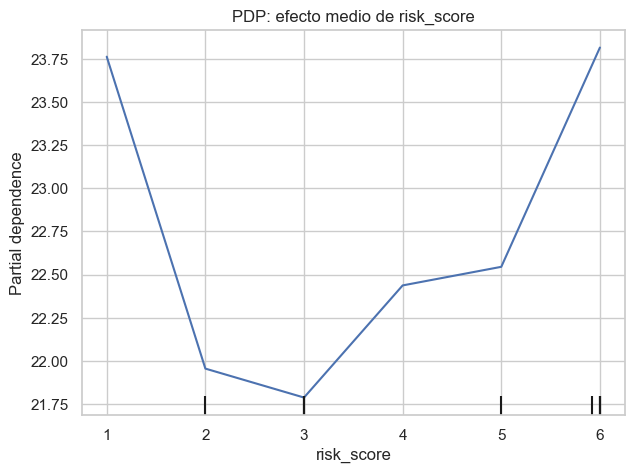

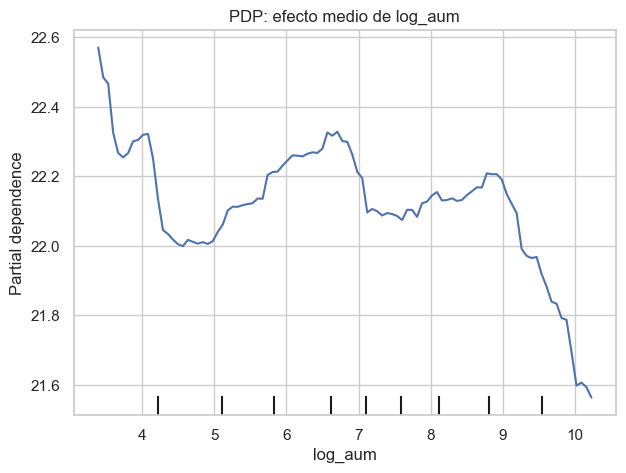

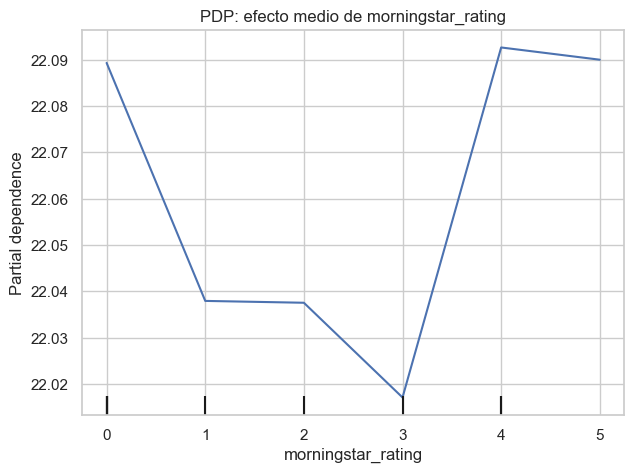

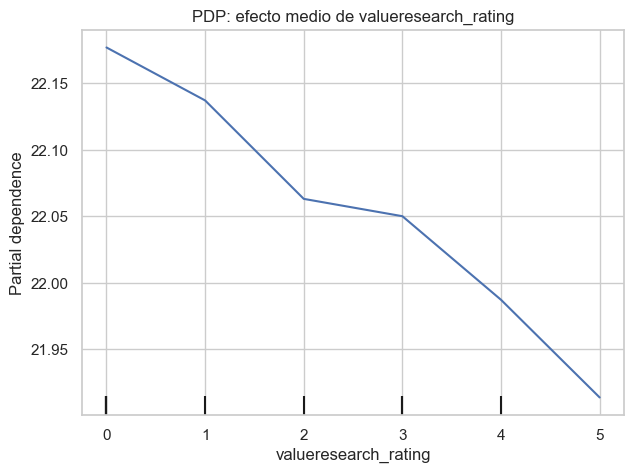

In [165]:
# ============================================================
# PDP e ICE sobre variables originales mediante pipeline completo
# ============================================================

# Para PDP/ICE se crea un pipeline que opera sobre variables originales, lo que facilita la lectura financiera.
pdp_reg_model = RandomForestRegressor(
    n_estimators=80,
    random_state=RANDOM_STATE,
    min_samples_leaf=3,
    n_jobs=1
)
main_reg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", pdp_reg_model)
])
main_reg_pipeline.fit(X_train_raw, y_train_reg)

pdp_candidate_features = [c for c in ["risk_score", "log_aum", "morningstar_rating", "valueresearch_rating", "return_1m", "return_3y"] if c in X_train_raw.columns]
pdp_features = pdp_candidate_features[:4]

for feat in pdp_features:
    fig, ax = plt.subplots(figsize=(7, 5))
    PartialDependenceDisplay.from_estimator(
        main_reg_pipeline,
        X_train_raw,
        [feat],
        kind="average",
        ax=ax
    )
    plt.title(f"PDP: efecto medio de {feat}")
    plt.show()

> Los *Partial Dependence Plots* muestran el efecto medio de cada variable sobre la predicción del modelo. En `risk_score` se observa una relación no monotónica: los niveles intermedios de riesgo presentan menores predicciones medias, mientras que los niveles extremos muestran valores más elevados. Esto sugiere que el modelo no aprende una relación lineal simple entre riesgo y retorno esperado.

> En `log_aum` aparece un comportamiento relativamente estable en valores intermedios, seguido de una caída en fondos de mayor tamaño. El modelo, por tanto, no parece asociar automáticamente un mayor volumen gestionado con mejores retornos esperados.

> Por su parte, `morningstar_rating` muestra un efecto moderadamente positivo para ratings altos, aunque con diferencias reducidas entre niveles. En cambio, `valueresearch_rating` presenta una tendencia ligeramente decreciente, lo que indica que esta variable tiene una influencia limitada y posiblemente inestable dentro del modelo. Los PDP resumen el comportamiento medio del modelo, pero los gráficos ICE muestran que algunos fondos reaccionan de forma bastante distinta ante cambios en las mismas variables (a continuación).

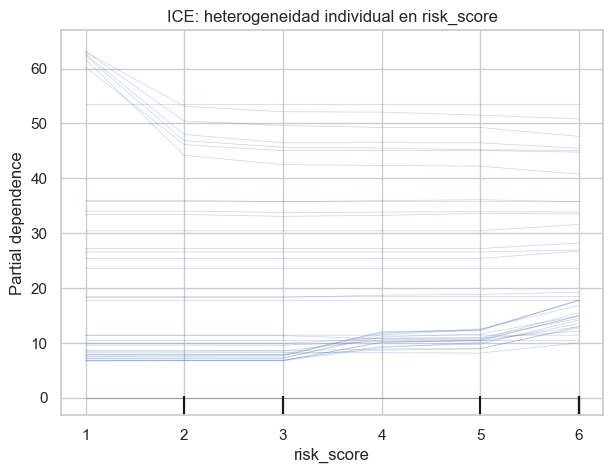

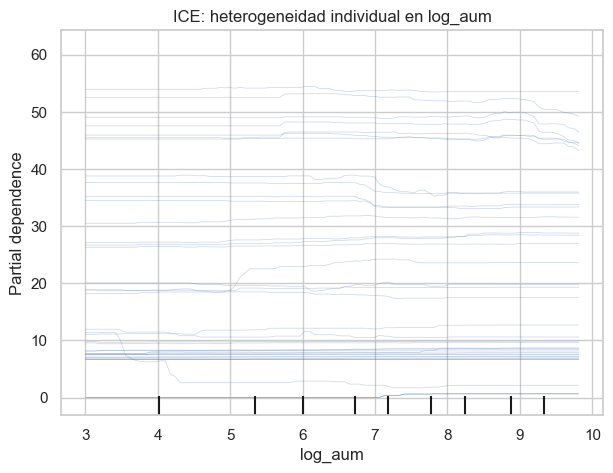

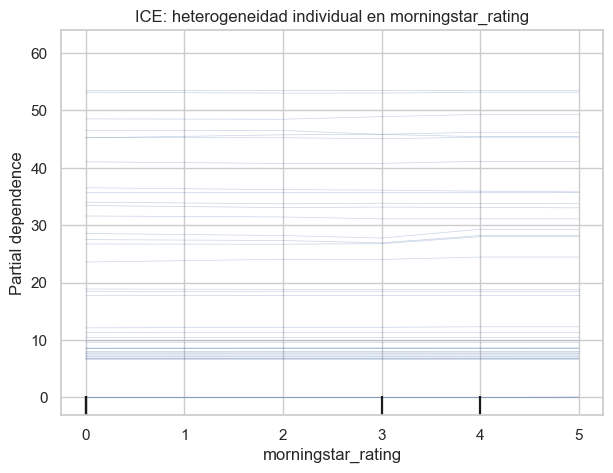

In [169]:
# ICE plots
for feat in pdp_features[:3]:
    fig, ax = plt.subplots(figsize=(7, 5))
    PartialDependenceDisplay.from_estimator(
        main_reg_pipeline,
        X_train_raw.sample(min(150, len(X_train_raw)), random_state=RANDOM_STATE),
        [feat],
        kind="individual",
        subsample=40,
        random_state=RANDOM_STATE,
        ax=ax
    )
    plt.title(f"ICE: heterogeneidad individual en {feat}")
    plt.show()

> Los gráficos ICE muestran una heterogeneidad relevante entre fondos. En `risk_score`, algunas trayectorias aumentan con niveles altos de riesgo mientras otras permanecen relativamente estables, lo que indica que el impacto del riesgo depende del perfil específico del fondo y de sus interacciones con otras variables.

> En `log_aum` se observa igualmente un comportamiento heterogéneo: ciertos fondos reducen su predicción a medida que aumenta el tamaño gestionado, mientras otros apenas muestran variación. El efecto del volumen gestionado, por tanto, no es uniforme en toda la muestra.

> Por el contrario, `morningstar_rating` presenta curvas mucho más paralelas y estables, lo que sugiere un efecto relativamente homogéneo y moderado entre fondos.

> La dispersión entre curvas es especialmente visible en risk_score y log_aum, donde algunos fondos apenas cambian su predicción y otros muestran variaciones mucho más pronunciadas, aspecto especialmente relevante en contextos principal-agente donde la interpretación de cada fondo concreto resulta esencial para la supervisión y la confianza del inversor.

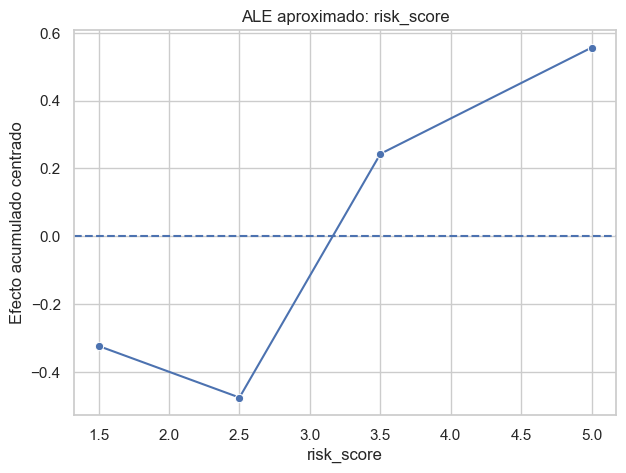

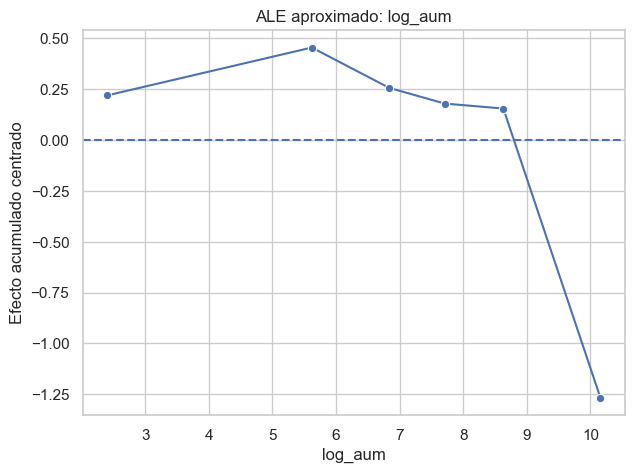

In [176]:
# ============================================================
# ALE simplificado para variables numéricas
# ============================================================

def compute_ale_1d(model, X_raw, feature, bins=10):
    """Calcula ALE 1D aproximado para un pipeline que recibe variables originales."""
    x = X_raw[feature].copy()
    valid = x.dropna()
    quantiles = np.unique(np.quantile(valid, np.linspace(0, 1, bins + 1)))
    if len(quantiles) < 3:
        raise ValueError("No hay suficientes valores únicos para ALE.")

    effects = []
    centers = []
    for low, high in zip(quantiles[:-1], quantiles[1:]):
        mask = (x >= low) & (x <= high)
        X_bin = X_raw.loc[mask].copy()
        if len(X_bin) == 0:
            effects.append(0.0)
            centers.append((low + high) / 2)
            continue
        X_low = X_bin.copy()
        X_high = X_bin.copy()
        X_low[feature] = low
        X_high[feature] = high
        diff = model.predict(X_high) - model.predict(X_low)
        effects.append(np.mean(diff))
        centers.append((low + high) / 2)

    ale = np.cumsum(effects)
    ale = ale - np.mean(ale)
    return pd.DataFrame({"center": centers, "ale": ale})

ale_sample = X_train_raw.sample(min(250, len(X_train_raw)), random_state=RANDOM_STATE)

for feat in pdp_features[:2]:
    try:
        ale_df = compute_ale_1d(main_reg_pipeline, ale_sample, feat, bins=6)
        plt.figure(figsize=(7, 5))
        sns.lineplot(data=ale_df, x="center", y="ale", marker="o")
        plt.axhline(0, linestyle="--")
        plt.title(f"ALE aproximado: {feat}")
        plt.xlabel(feat)
        plt.ylabel("Efecto acumulado centrado")
        plt.show()
    except Exception as exc:
        print(f"No se pudo calcular ALE para {feat}: {exc}")

> Los gráficos ALE muestran patrones coherentes con los resultados obtenidos mediante PDP e ICE, aunque con una interpretación más robusta en presencia de variables correlacionadas. En `risk_score` se observa que los niveles bajos e intermedios de riesgo tienden a reducir la predicción media, mientras que niveles altos generan contribuciones positivas más claras.

> En `log_aum` aparece un comportamiento relativamente estable para tamaños intermedios, seguido de una caída pronunciada en los fondos de mayor tamaño. Esto sugiere que el modelo no asocia necesariamente un mayor volumen gestionado con mejores retornos esperados.

> En este caso, ALE confirma en líneas generales lo observado en PDP, especialmente para `risk_score` y `log_aum`, aunque suaviza algunos cambios bruscos visibles en los gráficos anteriores. Las diferencias observadas en algunos tramos indican que las interacciones y correlaciones entre variables financieras siguen siendo relevantes para la interpretación.

### 4.4 Explicabilidad local: fondos concretos

Las explicaciones locales permiten examinar por qué el modelo asigna una predicción concreta a un fondo individual. Esta perspectiva es esencial en una relación principal-agente, ya que el inversor puede necesitar justificar por qué un algoritmo recomienda, descarta o prioriza un fondo específico.

Se seleccionan cuatro casos. \1
1. fondo con retorno observado alto;
2. fondo con retorno observado bajo;
3. fondo con alto nivel de riesgo;
4. fondo cercano a la mediana de retorno.

In [184]:
# ============================================================
# Selección de casos individuales
# ============================================================

test_df = df.loc[test_idx].copy()
test_df["pred_return_1y"] = reg_pred
test_df["pred_top_proba"] = clf_proba

def safe_idxmax(series):
    return series.dropna().idxmax()

def safe_idxmin(series):
    return series.dropna().idxmin()

case_indices = {
    "retorno_observado_alto": safe_idxmax(test_df["return_1y"]),
    "retorno_observado_bajo": safe_idxmin(test_df["return_1y"]),
    "riesgo_alto": safe_idxmax(test_df["risk_score"]),
    "caso_mediano": (test_df["return_1y"] - test_df["return_1y"].median()).abs().idxmin(),
}

cases = test_df.loc[list(case_indices.values()), [
    "fund_name", "amc", "fund_manager", "category", "risk", "return_1y", "pred_return_1y", "top_fund", "pred_top_proba"
]]
cases.index = list(case_indices.keys())
cases

,fund_name,amc,fund_manager,category,risk,return_1y,pred_return_1y,top_fund,pred_top_proba
retorno_observado_alto,HDFC Defence Reg-G,hdfc mutual fund,Priya Ranjan,Equity,Very High,86.35,27.095475,1,0.599490
retorno_observado_bajo,Kotak BSE PSU Index Reg-G,kotak mahindra mutual fund,Abhishek Bisen,Other,Low,0.00,1.742664,0,0.039462
riesgo_alto,Franklin India Feeder Franklin US Opp-G,franklin templeton mutual fund,Sandeep Manam,Other,Very High,31.44,24.034314,0,0.427776
caso_mediano,HSBC Global Equity Climate Change FoF Reg-G,hsbc mutual fund,Sonal Gupta,Other,Very High,15.39,13.929910,0,0.121866


> La selección de casos individuales cubre perfiles extremos y centrales: alto retorno, bajo retorno, alto riesgo y caso medio. Esta diversidad permite contrastar cómo cambian las explicaciones locales según el tipo de fondo. No debe generalizarse desde un único waterfall o force plot; la explicación local es una auditoría del caso.

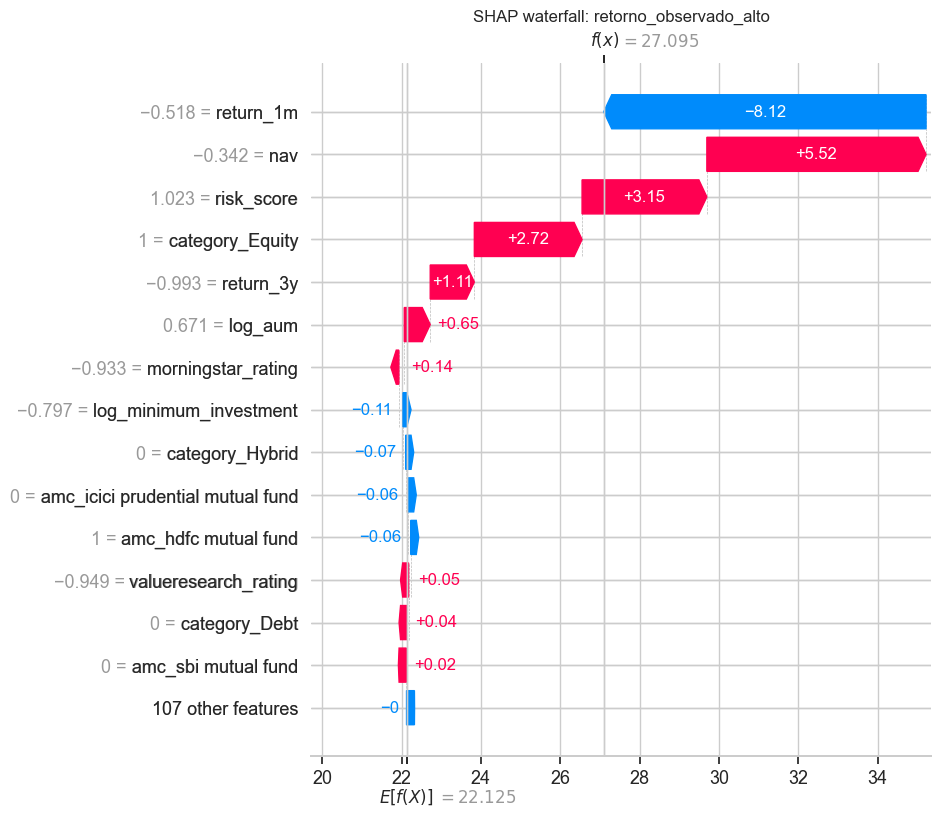

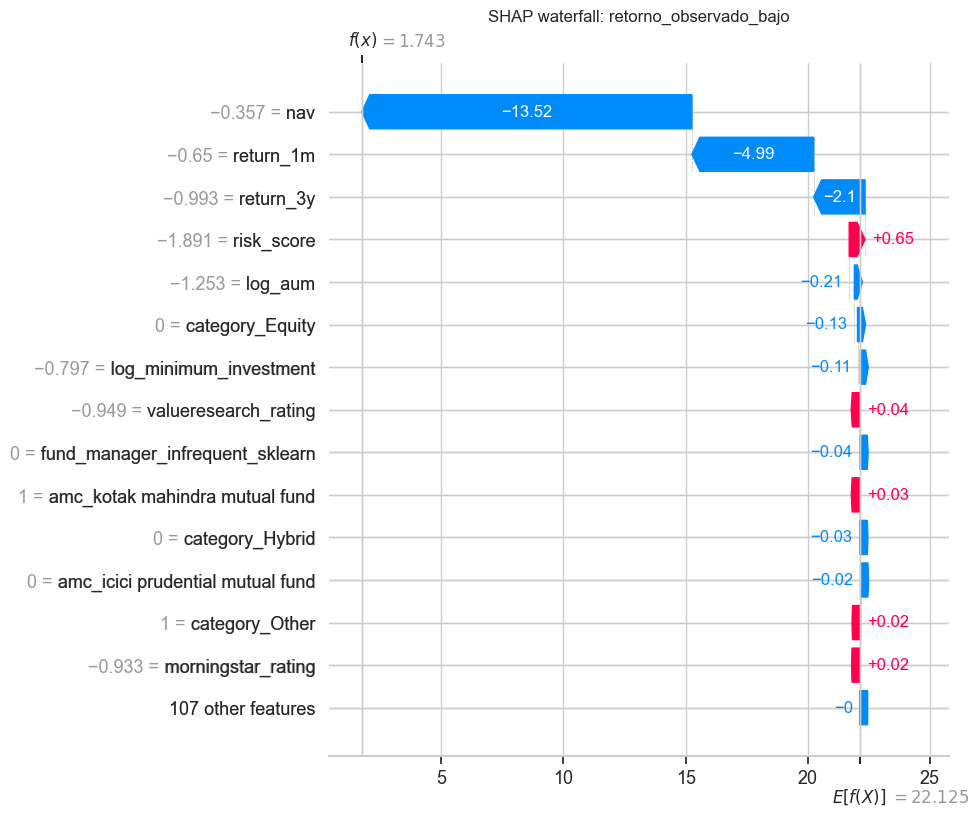

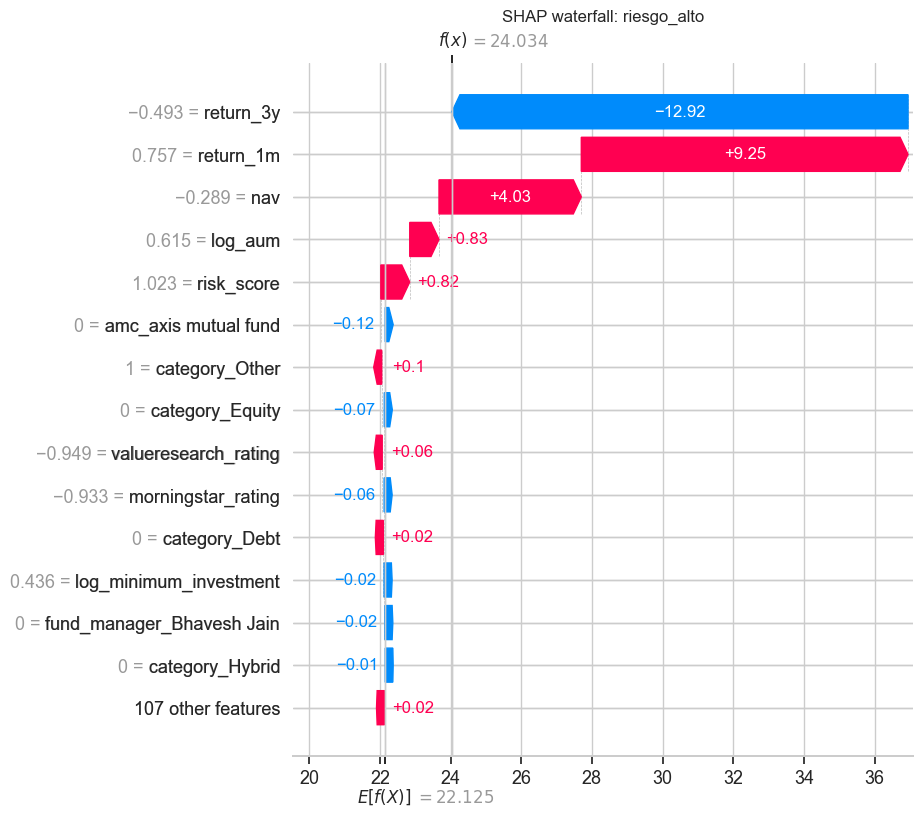

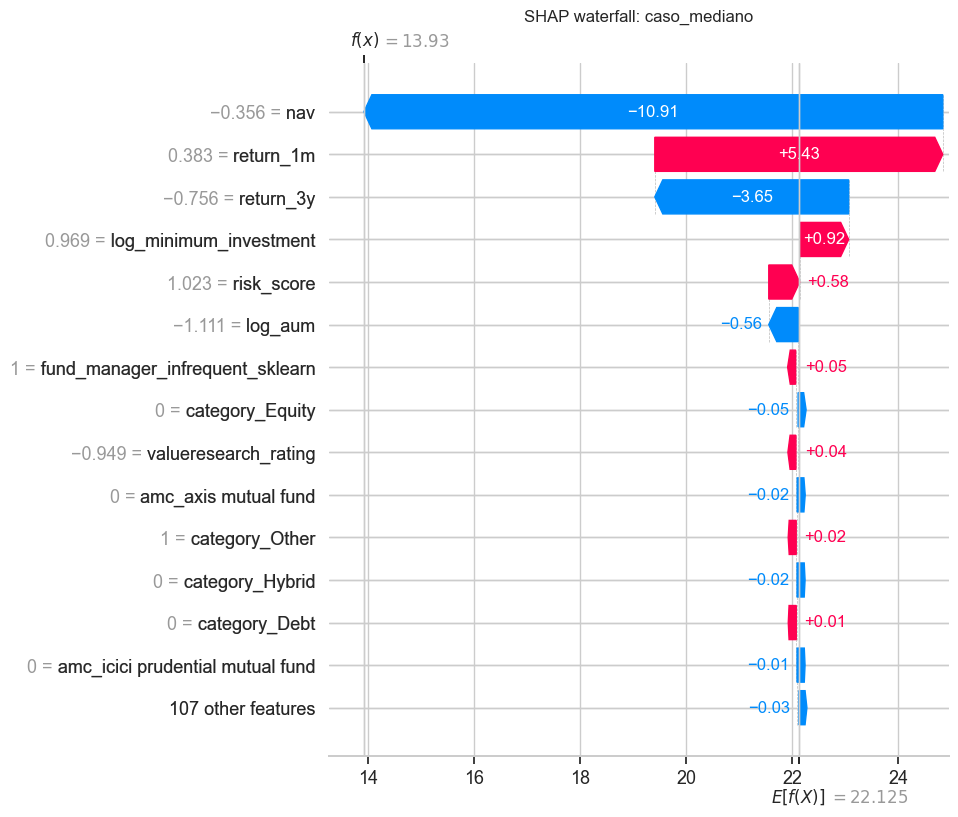

In [191]:
# ============================================================
# SHAP waterfall plots
# ============================================================

if shap_available:
    for label, original_idx in case_indices.items():
        if original_idx not in X_test_model.index:
            continue
        transformed_row = X_test_model.loc[[original_idx]]
        try:
            row_explanation = explainer_reg(transformed_row)
        except Exception:
            row_explanation = shap_values_reg[[list(shap_test_sample.index).index(original_idx)]] if original_idx in shap_test_sample.index else None
        if row_explanation is None:
            print(f"El caso {label} no está en la muestra SHAP utilizada.")
            continue
        shap.plots.waterfall(row_explanation[0], max_display=15, show=False)
        plt.title(f"SHAP waterfall: {label}")
        plt.show()

> Los *waterfall plots* muestran cómo cada variable desplaza la predicción individual desde el valor base del modelo hasta el valor final estimado para cada fondo. En los casos analizados, `return_1m`, `return_3y` y `nav` son las variables que generan los mayores desplazamientos positivos o negativos.

> En los fondos con predicciones elevadas, los retornos recientes positivos y determinadas combinaciones de NAV y categoría Equity incrementan significativamente la predicción final. Por el contrario, en los casos con predicciones bajas predominan contribuciones negativas asociadas principalmente a retornos históricos desfavorables y valores reducidos de NAV.

> También se observa que variables como `risk_score`, `log_aum` o los ratings suelen tener efectos secundarios frente al peso dominante de los retornos históricos. Esto confirma que el modelo depende principalmente de señales de desempeño previo más que de características estructurales del fondo. Desde una perspectiva de gobernanza algorítmica, estas explicaciones permiten justificar decisiones individuales del modelo y detectar qué variables están condicionando cada predicción concreta.

In [195]:
# SHAP force plots como HTML interactivo, cuando el entorno lo permite.
if shap_available:
    shap.initjs()
    first_case_idx = list(case_indices.values())[0]
    first_case_row = X_test_model.loc[[first_case_idx]]
    try:
        first_case_exp = explainer_reg(first_case_row)
        display(shap.plots.force(first_case_exp[0]))
    except Exception as exc:
        print("No se pudo mostrar force plot interactivo en este entorno:", exc)


> El *force plot* representa visualmente la tensión entre variables que incrementan y reducen la predicción individual del modelo. En el ejemplo mostrado, variables como `category_Equity`, `risk_score`, `nav` y `return_3y` empujan la predicción al alza, mientras que `return_1m` genera una contribución negativa dominante que reduce parcialmente la predicción final. La visualización permite identificar rápidamente qué variables tienen mayor peso relativo en cada decisión individual del modelo y cómo interactúan para desplazar la predicción desde el valor base hasta el valor final estimado. Su principal utilidad es interpretativa y comunicativa, especialmente para auditoría y explicabilidad local, aunque no debe interpretarse como evidencia causal sobre el comportamiento financiero del fondo.


### 4.5 LIME: explicaciones locales mediante aproximaciones lineales

LIME genera explicaciones locales entrenando un modelo interpretable alrededor de una observación perturbada. La intuición es aproximar localmente la frontera de decisión o la función predictiva compleja mediante una explicación lineal sencilla.

Su principal ventaja es la flexibilidad: puede aplicarse a diferentes modelos. Su principal limitación es la sensibilidad a la vecindad local, al muestreo de perturbaciones y a la representación de variables categóricas codificadas.

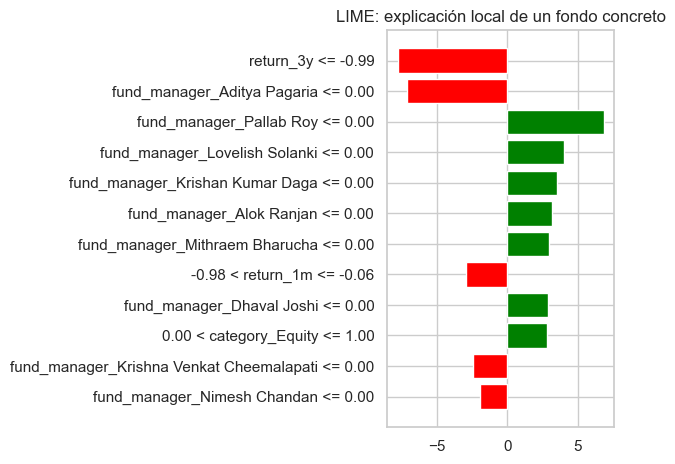

In [199]:
# ============================================================
# LIME para regresión
# ============================================================

try:
    from lime.lime_tabular import LimeTabularExplainer
    lime_available = True
except Exception as exc:
    lime_available = False
    print("LIME no está disponible en este entorno:", exc)

if lime_available:
    lime_explainer_reg = LimeTabularExplainer(
        training_data=X_train_model.values,
        feature_names=list(X_train_model.columns),
        mode="regression",
        discretize_continuous=True,
        random_state=RANDOM_STATE
    )

    selected_idx = list(case_indices.values())[0]
    row_values = X_test_model.loc[selected_idx].values

    lime_exp = lime_explainer_reg.explain_instance(
        data_row=row_values,
        predict_fn=main_reg_model.predict,
        num_features=12
    )

    fig = lime_exp.as_pyplot_figure()
    plt.title("LIME: explicación local de un fondo concreto")
    plt.tight_layout()
    plt.show()

else:
    print("LIME no disponible. Activar instalación automática o instalar 'lime' manualmente.")

> El gráfico de LIME muestra qué variables empujan localmente la predicción hacia valores más altos (verde) o más bajos (rojo) para el fondo analizado. La contribución negativa más importante corresponde a `return_3y <= -0.99`, lo que indica que el mal desempeño histórico a tres años reduce significativamente la predicción del modelo. También `return_1m` presenta un efecto negativo moderado.

> Por el contrario, varias variables asociadas a gestores concretos y la categoría `Equity` generan contribuciones positivas que compensan parcialmente el efecto negativo de los retornos históricos. Esto sugiere que, en este caso concreto, el modelo interpreta ciertas características categóricas y de gestión como señales favorables pese al bajo desempeño pasado. La explicación refleja que la predicción final no depende de una única variable, sino de la combinación local de retornos, categoría y características asociadas al gestor del fondo.


### 4.6 Contrafactuales simplificados

Una explicación contrafactual pregunta qué cambios mínimos harían variar la decisión del modelo. En este cuaderno se usa una aproximación sencilla: para un fondo que no se clasifica como `top_fund`, se modifican gradualmente variables numéricas relevantes dentro de rangos observados y se evalúa si la probabilidad predicha supera un umbral.

En finanzas, los contrafactuales deben interpretarse con prudencia: no todas las variables son accionables. Por ejemplo, aumentar el rating o reducir el riesgo no es una intervención directa instantánea, sino el resultado de procesos de gestión, mercado y evaluación externa.

,fund_name,amc,fund_manager,category,risk,return_1y,top_fund
477,Taurus Banking & Financial Services Reg-G,taurus mutual fund,Hardik Shah,Equity,Very High,19.34,0


,feature_changed,new_value,base_proba,new_proba,delta_proba,crosses_0_5
11,log_aum,6.467181,0.401304,0.504126,0.102822,True
12,log_aum,7.223941,0.401304,0.499081,0.097777,False
13,log_aum,7.980702,0.401304,0.479457,0.078153,False
10,log_aum,5.710420,0.401304,0.472006,0.070702,False
15,log_aum,9.494224,0.401304,0.465820,0.064516,False
14,log_aum,8.737463,0.401304,0.464672,0.063368,False
31,return_1m,6.870000,0.401304,0.428579,0.027275,False
0,risk_score,2.000000,0.401304,0.417864,0.016560,False
5,risk_score,4.857143,0.401304,0.417569,0.016265,False
6,risk_score,5.428571,0.401304,0.417569,0.016265,False


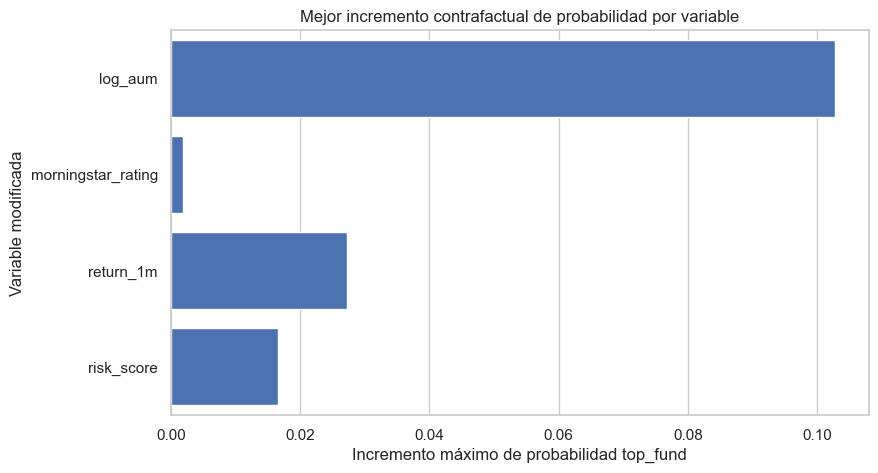

In [217]:
# ============================================================
# Contrafactual simplificado para clasificación
# ============================================================

cf_clf_model = RandomForestClassifier(
    n_estimators=80,
    random_state=RANDOM_STATE,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    n_jobs=1
)
main_clf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", cf_clf_model)
])
main_clf_pipeline.fit(X_train_raw, y_train_clf)

# Selección de un fondo inicialmente no clasificado como top con probabilidad intermedia.
non_top_candidates = test_df[test_df["pred_top_proba"] < 0.5].copy()
if len(non_top_candidates) == 0:
    print("No hay candidatos no top según el modelo. Se omite contrafactual.")
else:
    candidate_idx = (non_top_candidates["pred_top_proba"] - 0.4).abs().idxmin()
    base_instance = X.loc[[candidate_idx]].copy()
    base_proba = main_clf_pipeline.predict_proba(base_instance)[0, 1]

    mutable_numeric = [c for c in ["risk_score", "log_aum", "morningstar_rating", "return_1m"] if c in X.columns]
    counterfactual_records = []

    for feat in mutable_numeric:
        grid = np.linspace(X[feat].quantile(0.10), X[feat].quantile(0.90), 8)
        for value in grid:
            modified = base_instance.copy()
            modified[feat] = value
            proba = main_clf_pipeline.predict_proba(modified)[0, 1]
            counterfactual_records.append({
                "feature_changed": feat,
                "new_value": value,
                "base_proba": base_proba,
                "new_proba": proba,
                "delta_proba": proba - base_proba,
                "crosses_0_5": proba >= 0.5,
            })

    cf_df = pd.DataFrame(counterfactual_records).sort_values(["crosses_0_5", "delta_proba"], ascending=[False, False])
    display(df.loc[[candidate_idx], ["fund_name", "amc", "fund_manager", "category", "risk", "return_1y", "top_fund"]])
    display(cf_df.head(15))

    plt.figure(figsize=(9, 5))
    sns.barplot(data=cf_df.groupby("feature_changed", as_index=False)["delta_proba"].max(), x="delta_proba", y="feature_changed", saturation=1, color="C0")
    plt.title("Mejor incremento contrafactual de probabilidad por variable")
    plt.xlabel("Incremento máximo de probabilidad top_fund")
    plt.ylabel("Variable modificada")
    plt.show()


> El análisis contrafactual muestra qué modificaciones producirían el mayor incremento en la probabilidad de que el fondo sea clasificado como `top_fund`. En este caso, la variable con mayor impacto es claramente `log_aum`: incrementos simulados en el volumen gestionado elevan significativamente la probabilidad predicha, llegando incluso a superar el umbral de clasificación del 50%.

> Por el contrario, cambios en `risk_score`, `return_1m` o `morningstar_rating` generan mejoras mucho más reducidas. Esto sugiere que, para este fondo concreto, el modelo interpreta el tamaño del fondo como una señal más relevante que pequeñas variaciones en riesgo o rendimiento reciente.

> El resultado es especialmente interesante porque difiere parcialmente de los análisis globales anteriores: aunque `log_aum` tenía una importancia moderada a nivel agregado, en este caso concreto adquiere un papel decisivo. Esto ilustra cómo las explicaciones locales pueden revelar dependencias específicas que quedan ocultas en métricas globales de importancia. No obstante, estos contrafactuales deben interpretarse como herramientas de diagnóstico del comportamiento del modelo y no como recomendaciones financieras operativas o relaciones causales reales.


### 4.7 Surrogate trees: explicabilidad estructural

Un **surrogate tree** es un árbol interpretable entrenado para aproximar las predicciones de un modelo complejo. No explica directamente el fenómeno financiero, sino el comportamiento del modelo black-box.

Su calidad depende de la fidelidad. \1
$$
\text{Fidelidad} = R^2\left(\hat{f}_{black-box}(X), \hat{f}_{surrogate}(X)\right)
$$

Una fidelidad alta indica que el árbol captura razonablemente la lógica del modelo complejo. Una fidelidad baja indica que las reglas simples no son suficientes para representar su comportamiento.

Fidelidad del surrogate tree respecto al modelo Random Forest: R² = 0.723


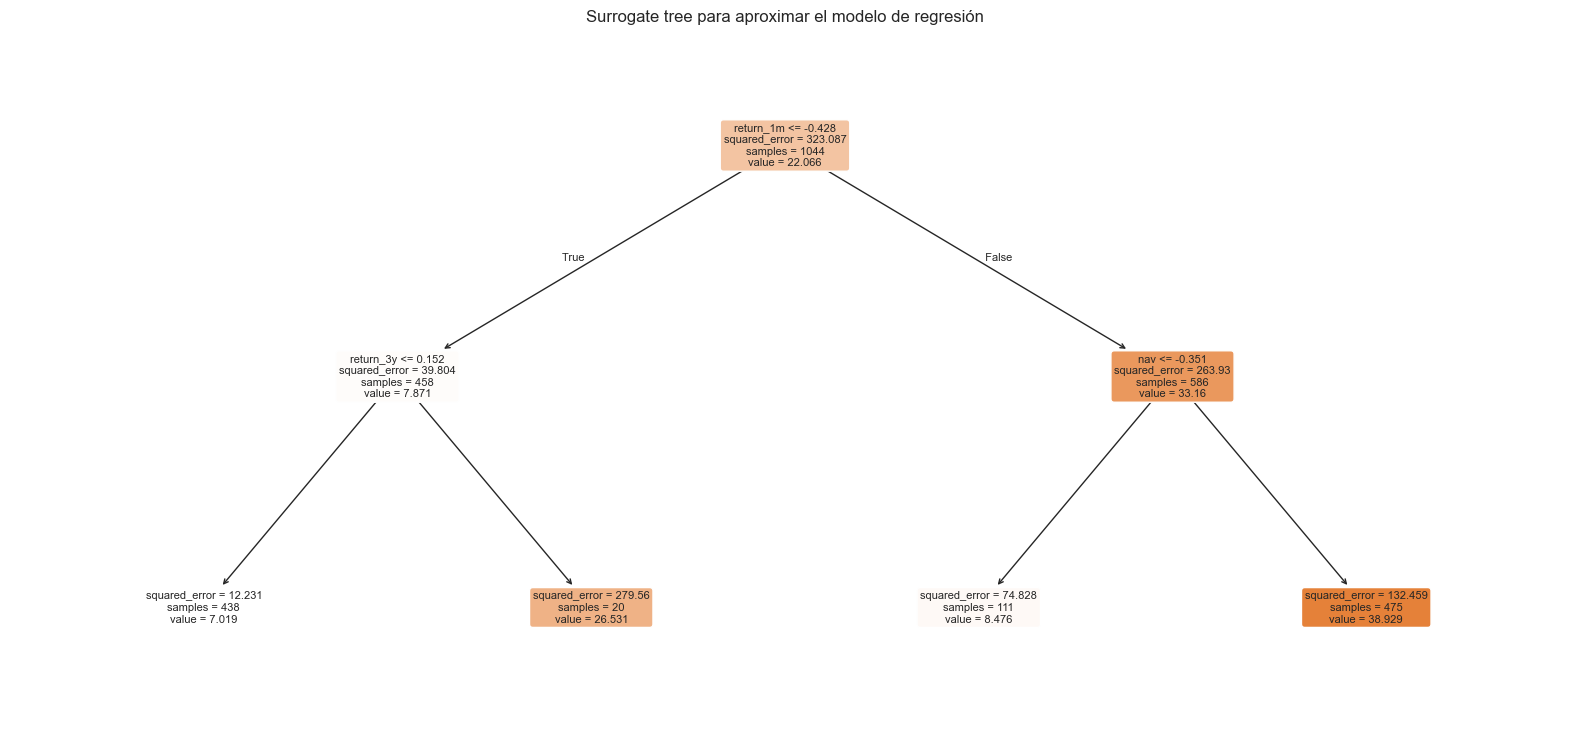

In [223]:
# ============================================================
# Árbol sustituto para regresión
# ============================================================

black_box_train_pred = main_reg_model.predict(X_train_model)
black_box_test_pred = main_reg_model.predict(X_test_model)

surrogate_reg = DecisionTreeRegressor(max_depth=2, min_samples_leaf=20, random_state=RANDOM_STATE)
surrogate_reg.fit(X_train_model, black_box_train_pred)
surrogate_pred = surrogate_reg.predict(X_test_model)
surrogate_fidelity = r2_score(black_box_test_pred, surrogate_pred)

print(f"Fidelidad del surrogate tree respecto al modelo {main_reg_name}: R² = {surrogate_fidelity:.3f}")

plt.figure(figsize=(20, 9))
plot_tree(
    surrogate_reg,
    feature_names=list(feature_names),
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=8
)
plt.title("Surrogate tree para aproximar el modelo de regresión")
plt.show()


> El *surrogate tree* resume el comportamiento general del modelo complejo mediante un conjunto reducido de reglas interpretables. En este caso, las primeras divisiones se realizan sobre `return_1m`, `return_3y` y `nav`, lo que confirma que estas variables dominan la lógica predictiva del modelo también desde una perspectiva estructural.

> El árbol muestra que retornos recientes bajos tienden a conducir hacia predicciones reducidas, mientras que combinaciones de retornos positivos y determinados valores de NAV desplazan la predicción hacia niveles más altos. Las ramas superiores concentran gran parte de la capacidad explicativa, lo que sugiere que unas pocas variables capturan una proporción importante del comportamiento global del modelo. No obstante, el surrogate tree constituye una simplificación aproximada del modelo original.

In [224]:
# Reglas textuales del surrogate tree
rules_text = export_text(surrogate_reg, feature_names=list(feature_names), max_depth=3)
print(rules_text[:4000])

|--- return_1m <= -0.43
|   |--- return_3y <= 0.15
|   |   |--- value: [7.02]
|   |--- return_3y >  0.15
|   |   |--- value: [26.53]
|--- return_1m >  -0.43
|   |--- nav <= -0.35
|   |   |--- value: [8.48]
|   |--- nav >  -0.35
|   |   |--- value: [38.93]



### 4.8 Comparación entre explicaciones

Una buena auditoría XAI no debería depender de un único método. Las explicaciones pueden diferir porque cada técnica responde a una pregunta distinta. \1
- Los coeficientes lineales describen relaciones paramétricas bajo supuestos restrictivos.
- La importancia nativa describe uso interno del modelo.
- Permutation importance mide deterioro predictivo al alterar variables.
- SHAP atribuye contribuciones marginales bajo un esquema aditivo.
- LIME aproxima localmente el modelo con una explicación simple.

La convergencia entre métodos aumenta la confianza interpretativa. La divergencia exige cautela y análisis adicional.

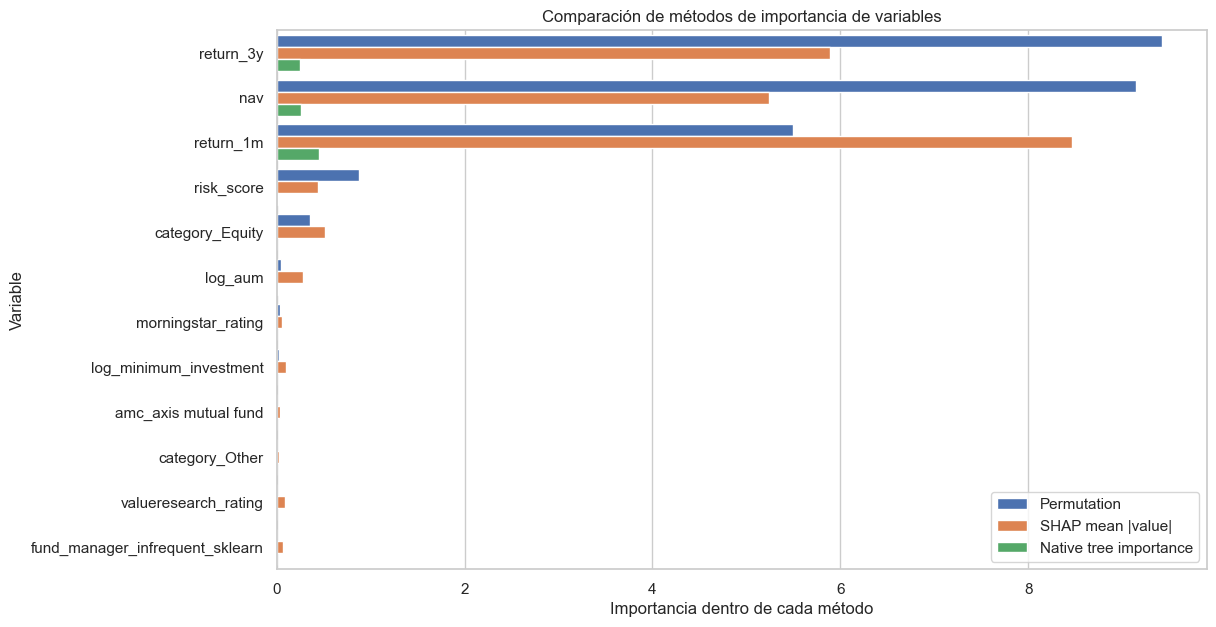

In [231]:
# ============================================================
# Comparación de rankings de importancia
# ============================================================

comparison_frames = []

# Permutation importance
comparison_frames.append(
    perm_reg_df[["feature", "importance_mean"]]
    .rename(columns={"importance_mean": "importance"})
    .assign(method="Permutation")
)

# SHAP mean absolute
if shap_available:
    shap_importance_df = pd.DataFrame({
        "feature": shap_test_sample.columns,
        "importance": np.abs(shap_values_reg.values).mean(axis=0),
        "method": "SHAP mean |value|"
    })
    comparison_frames.append(shap_importance_df)

# Native importance
if hasattr(main_reg_model, "feature_importances_"):
    comparison_frames.append(
        pd.DataFrame({
            "feature": feature_names,
            "importance": main_reg_model.feature_importances_,
            "method": "Native tree importance"
        })
    )

importance_comparison = pd.concat(comparison_frames, ignore_index=True)
importance_comparison["rank"] = importance_comparison.groupby("method")["importance"].rank(ascending=False, method="min")

top_features_union = (
    importance_comparison.sort_values("rank")
    .groupby("method")
    .head(10)["feature"]
    .unique()
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=importance_comparison[importance_comparison["feature"].isin(top_features_union)],
    y="feature",
    x="importance",
    hue="method",
    saturation=1
)
plt.title("Comparación de métodos de importancia de variables")
plt.xlabel("Importancia dentro de cada método")
plt.ylabel("Variable")
plt.legend(loc="best")
plt.show()


__Comparación entre métodos de importancia de variables:__

> La comparación entre *Permutation Importance*, SHAP y la importancia nativa del árbol muestra una convergencia clara en torno a `return_1m`, `return_3y` y `nav` como variables dominantes del modelo. Aunque la magnitud relativa cambia entre métodos, los tres coinciden en identificar los retornos históricos y el NAV como los principales determinantes de la predicción.

> Las diferencias más visibles aparecen en variables secundarias como `risk_score`, `log_aum` y `category_Equity`, cuya relevancia varía según la técnica utilizada. SHAP y Permutation Importance asignan mayor peso a estas variables que la importancia nativa del árbol, lo que sugiere que parte de su efecto depende de interacciones y contribuciones marginales no capturadas completamente por las métricas internas del modelo.

> La divergencia parcial entre métodos no implica inconsistencia, sino que refleja que cada técnica mide aspectos distintos del comportamiento predictivo: sensibilidad global, contribución marginal o frecuencia estructural de uso dentro del modelo.


### 4.9 Estabilidad de SHAP

Una explicación no sólo debe ser intuitiva; también debe ser estable. La estabilidad se examina reentrenando modelos con distintas semillas y comparando la importancia SHAP media absoluta. Si el ranking de variables cambia drásticamente, la explicación puede ser frágil.

Se pueden elegir muestras del conjunto de datos para reducir los tiempos de ejecución.

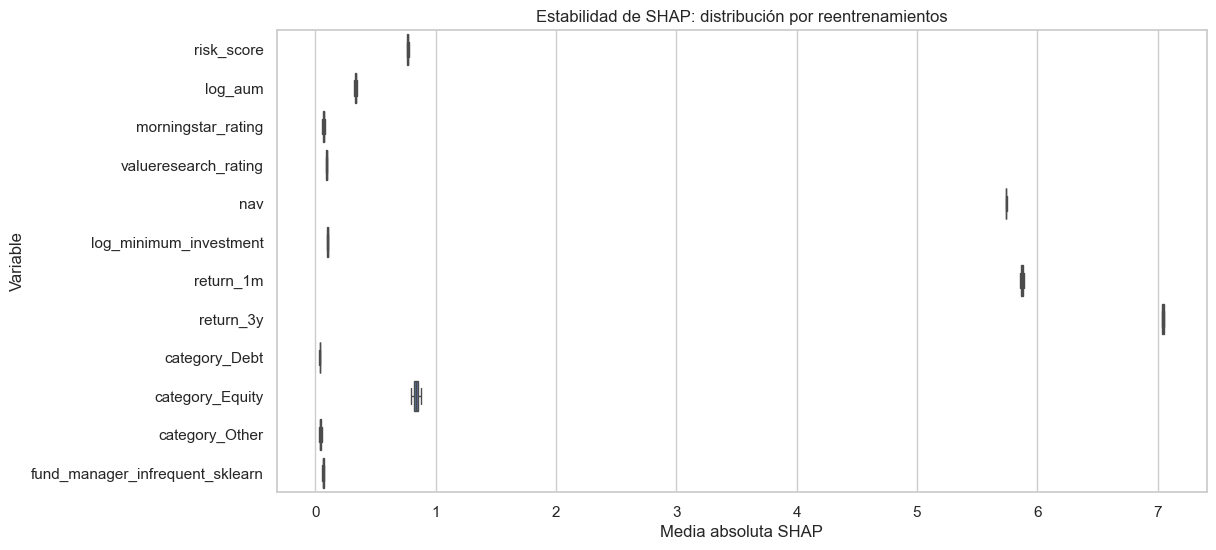

,mean,std
feature,,
return_3y,7.044430,0.015763
return_1m,5.873566,0.026337
nav,5.741213,0.006437
category_Equity,0.836498,0.054333
risk_score,0.768217,0.012820
log_aum,0.334350,0.013700
log_minimum_investment,0.102653,0.008486
valueresearch_rating,0.093233,0.005645
morningstar_rating,0.067776,0.021115


In [236]:
# ============================================================
# Estabilidad aproximada de SHAP por reentrenamiento
# ============================================================

if RUN_SHAP_STABILITY and shap_available and main_reg_name in ["Random Forest", "XGBoost", "LightGBM", "HistGradientBoosting"]:
    seeds = [11, 42]
    stability_records = []
    shap_eval_sample = X_test_model.sample(min(180, len(X_test_model)), random_state=RANDOM_STATE)
    background = X_train_model.sample(min(300, len(X_train_model)), random_state=RANDOM_STATE)

    for seed in seeds:
        model_clone = clone(reg_models[main_reg_name]) if main_reg_name in reg_models else clone(main_reg_model)
        if hasattr(model_clone, "set_params"):
            try:
                model_clone.set_params(random_state=seed)
            except Exception:
                pass
        model_clone.fit(X_train_model, y_train_reg)
        try:
            expl = shap.Explainer(model_clone, background)
            sv = expl(shap_eval_sample)
            mean_abs = np.abs(sv.values).mean(axis=0)
            for feat, val in zip(shap_eval_sample.columns, mean_abs):
                stability_records.append({"seed": seed, "feature": feat, "mean_abs_shap": val})
        except Exception as exc:
            print(f"No se pudo calcular SHAP para semilla {seed}: {exc}")

    shap_stability_df = pd.DataFrame(stability_records)
    if len(shap_stability_df) > 0:
        top_stable_features = (
            shap_stability_df.groupby("feature")["mean_abs_shap"].mean()
            .sort_values(ascending=False)
            .head(12)
            .index
        )
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=shap_stability_df[shap_stability_df["feature"].isin(top_stable_features)], y="feature", x="mean_abs_shap")
        plt.title("Estabilidad de SHAP: distribución por reentrenamientos")
        plt.xlabel("Media absoluta SHAP")
        plt.ylabel("Variable")
        plt.show()

        display(
            shap_stability_df.groupby("feature")["mean_abs_shap"]
            .agg(["mean", "std"])
            .sort_values("mean", ascending=False)
            .head(15)
        )
else:
    print("El bloque de estabilidad SHAP queda documentado pero no se ejecuta por defecto. Cambiar RUN_SHAP_STABILITY=True para activarlo.")

> El análisis de estabilidad muestra que las variables más importantes (especialmente `return_3y`, `return_1m` y `nav`) mantienen valores SHAP relativamente consistentes entre distintos reentrenamientos del modelo. La baja dispersión observada en estas variables sugiere que su relevancia es robusta y no depende de forma significativa de la semilla aleatoria utilizada.

> Por el contrario, variables secundarias como categorías, ratings o identificadores de gestores presentan valores SHAP mucho menores y una variabilidad relativamente más alta, lo que indica una importancia menos estable y potencialmente más sensible a pequeñas variaciones en los datos o en el entrenamiento.

> Estos resultados refuerzan la confianza en las conclusiones principales del modelo, especialmente en torno al peso dominante de los retornos históricos y del NAV dentro de la lógica predictiva aprendida.


### 4.10 Error analysis por categoría, riesgo, gestora y gestor

El análisis de errores es una pieza central de la gobernanza algorítmica. Un modelo puede tener buen desempeño promedio y, aun así, fallar sistemáticamente en determinados grupos. En asset management, esto podría traducirse en infraestimación de ciertos estilos de inversión o sobreestimación de determinadas gestoras.

In [240]:
# ============================================================
# Errores por grupos
# ============================================================

test_analysis = df.loc[test_idx].copy()
test_analysis["pred_return_1y"] = reg_pred
test_analysis["residual"] = test_analysis["return_1y"] - test_analysis["pred_return_1y"]
test_analysis["abs_error"] = test_analysis["residual"].abs()
test_analysis["pred_top_proba"] = clf_proba

def group_error_table(group_col, min_n=5):
    return (
        test_analysis.groupby(group_col)
        .agg(
            n=("fund_name", "count"),
            mean_return=("return_1y", "mean"),
            mean_pred=("pred_return_1y", "mean"),
            mae=("abs_error", "mean"),
            bias=("residual", "mean"),
            mean_top_proba=("pred_top_proba", "mean"),
        )
        .query("n >= @min_n")
        .sort_values("mae", ascending=False)
    )

for group_col, min_n in [("category", 3), ("risk", 3), ("amc", 5), ("fund_manager", 3)]:
    print(f"\nErrores por {group_col}")
    display(group_error_table(group_col, min_n=min_n).head(15))


Errores por category


,n,mean_return,mean_pred,mae,bias,mean_top_proba
category,,,,,,
Equity,111,37.421802,36.967035,6.396232,0.454766,0.687477
Other,98,19.772449,20.178832,4.136516,-0.406383,0.253232
Hybrid,42,18.666190,18.376725,2.412968,0.289466,0.116634
Debt,98,7.142347,7.206958,0.303241,-0.064611,0.015593



Errores por risk


,n,mean_return,mean_pred,mae,bias,mean_top_proba
risk,,,,,,
Very High,127,27.167402,27.072296,6.704107,0.095106,0.418579
High,37,36.337838,35.549281,4.317539,0.788557,0.603183
Moderately High,31,23.651935,22.914121,2.864692,0.737815,0.304269
Moderate,85,16.610235,16.961516,1.315039,-0.351280,0.202930
Low,30,12.763333,13.279685,0.805352,-0.516352,0.153969
Low to Moderate,38,6.650263,6.709979,0.275744,-0.059716,0.015902



Errores por amc


,n,mean_return,mean_pred,mae,bias,mean_top_proba
amc,,,,,,
quant mutual fund,7,40.050000,43.421572,9.564136,-3.371572,0.710976
lic mutual fund,11,24.799091,23.020259,5.987938,1.778832,0.254488
bandhan mutual fund,18,14.846111,17.787651,5.442182,-2.941540,0.246876
hdfc mutual fund,19,26.155789,24.112425,5.412173,2.043365,0.346787
uti mutual fund,19,23.038947,20.923828,5.392181,2.115120,0.307131
union mutual fund,6,26.371667,24.689764,5.075762,1.681902,0.383449
tata mutual fund,9,34.037778,33.263109,4.108551,0.774669,0.577063
icici prudential mutual fund,15,29.962667,31.695548,3.942519,-1.732882,0.467866
franklin templeton mutual fund,8,18.636250,17.966820,3.676484,0.669430,0.326663



Errores por fund_manager


,n,mean_return,mean_pred,mae,bias,mean_top_proba
fund_manager,,,,,,
Nemish Sheth,4,8.187500,20.392741,14.883196,-12.205241,0.312172
Sanjeev Sharma,5,35.006000,40.709157,11.949344,-5.703157,0.668961
Sharwan Kumar Goyal,6,28.115000,22.698461,11.534037,5.416539,0.285078
Aditya Mulki,3,24.980000,29.082460,8.497091,-4.102460,0.340296
Jay Kothari,3,13.416667,16.321607,6.287929,-2.904940,0.183360
Anand Radhakrishnan,3,34.356667,33.953852,6.249164,0.402814,0.579818
Sankaran Naren,4,21.327500,27.401764,6.074264,-6.074264,0.453791
V Srivatsa,3,42.333333,39.011237,5.834048,3.322096,0.746022
Krishan Kumar Daga,3,36.420000,36.505750,5.446943,-0.085750,0.556274


> El análisis segmentado muestra que el modelo presenta errores significativamente mayores en categorías Equity y en fondos con perfiles de riesgo elevados, especialmente `Very High` y `High`. En cambio, las categorías Debt y los perfiles `Low` o `Low to Moderate` presentan errores medios considerablemente más reducidos y predicciones más estables. Estos resultados sugieren que el modelo tiene mayores dificultades para capturar segmentos con elevada dispersión de retornos y comportamiento más volátil, mientras que los fondos más conservadores muestran patrones más predecibles.

> Por gestoras (*AMC*), se observan diferencias relevantes tanto en error medio como en sesgo. Algunas entidades presentan tendencias sistemáticas de sobrepredicción o infrapredicción, aunque estas conclusiones deben interpretarse con cautela debido al número limitado de fondos disponibles para determinadas gestoras.

> El análisis por gestor individual revela una heterogeneidad aún mayor. Algunos gestores presentan errores absolutos muy elevados y sesgos pronunciados, pero muchos casos corresponden a muestras extremadamente pequeñas (`n = 3–5`), lo que limita la robustez estadística de las conclusiones.

> Desde una perspectiva de gobernanza algorítmica, este tipo de análisis resulta especialmente relevante porque permite identificar segmentos donde el modelo es menos fiable y donde las predicciones deberían someterse a una supervisión adicional antes de utilizarse en procesos de decisión financiera.


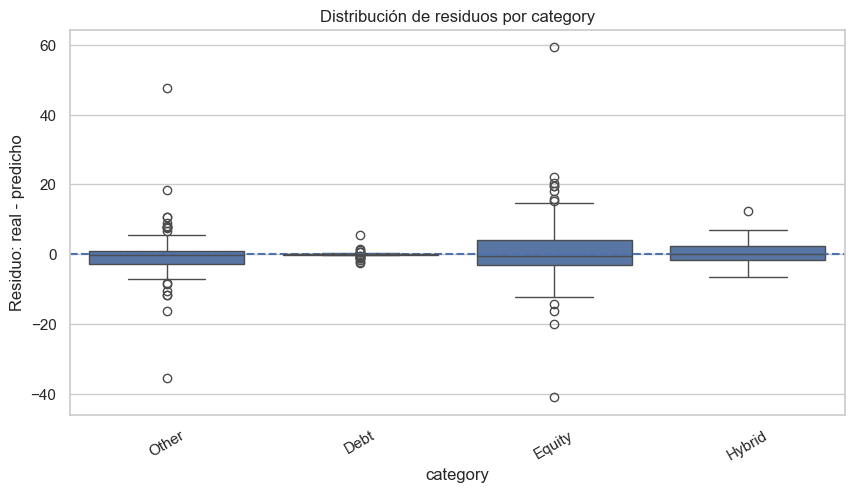

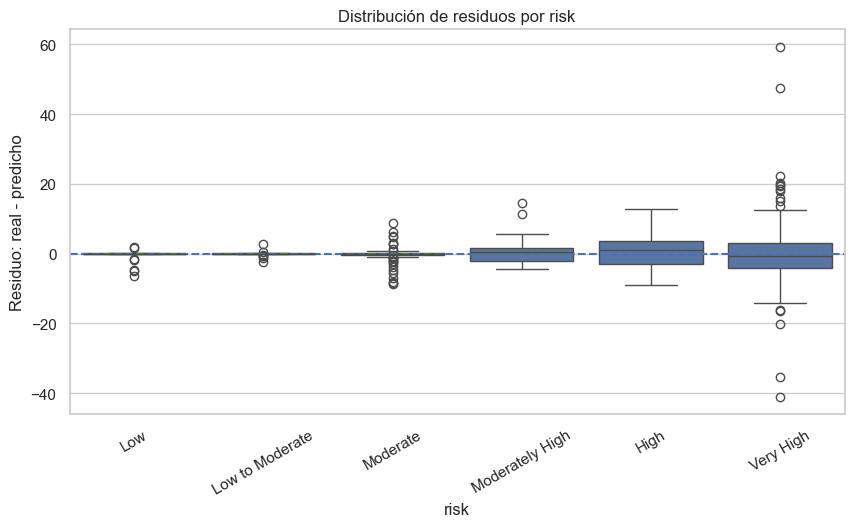

In [241]:
# Visualización de errores por categoría y riesgo
for group_col in ["category", "risk"]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=test_analysis, x=group_col, y="residual", order=risk_order_list if group_col == "risk" else None)
    plt.axhline(0, linestyle="--")
    plt.title(f"Distribución de residuos por {group_col}")
    plt.xlabel(group_col)
    plt.ylabel("Residuo: real - predicho")
    plt.xticks(rotation=30)
    plt.show()

> Los boxplots de residuos permiten identificar infrapredicción y sobrepredicción por grupo y son una representación gráfica de la interpretación anterior.

> También se observan varios *outliers* positivos y negativos, especialmente en Equity y `Very High`, donde aparecen casos de infrapredicción y sobrepredicción muy pronunciadas. Esto refleja la dificultad del modelo para capturar comportamientos extremos en segmentos de mercado más agresivos. En conjunto, los gráficos refuerzan la necesidad de realizar auditorías segmentadas del modelo antes de utilizar sus predicciones en contextos de recomendación o supervisión financiera.


### 4.11 Explicaciones agregadas por gestor y gestora

La agregación de predicciones, errores y contribuciones SHAP por gestor o gestora permite conectar el análisis técnico con el problema principal-agente. Si determinadas gestoras reciben predicciones altas por variables como riesgo, categoría o retorno histórico, la explicación puede revelar si el modelo está capturando habilidad diferencial o simplemente exposición a factores observables.

,n,mean_return,mean_pred,mae,bias,mean_top_proba
fund_manager,,,,,,
Nemish Sheth,4,8.187500,20.392741,14.883196,-12.205241,0.312172
Sanjeev Sharma,5,35.006000,40.709157,11.949344,-5.703157,0.668961
Sharwan Kumar Goyal,6,28.115000,22.698461,11.534037,5.416539,0.285078
Aditya Mulki,3,24.980000,29.082460,8.497091,-4.102460,0.340296
Jay Kothari,3,13.416667,16.321607,6.287929,-2.904940,0.183360
Anand Radhakrishnan,3,34.356667,33.953852,6.249164,0.402814,0.579818
Sankaran Naren,4,21.327500,27.401764,6.074264,-6.074264,0.453791
V Srivatsa,3,42.333333,39.011237,5.834048,3.322096,0.746022
Krishan Kumar Daga,3,36.420000,36.505750,5.446943,-0.085750,0.556274


,n,mean_return,mean_pred,mae,bias,mean_top_proba
amc,,,,,,
quant mutual fund,7,40.050000,43.421572,9.564136,-3.371572,0.710976
lic mutual fund,11,24.799091,23.020259,5.987938,1.778832,0.254488
bandhan mutual fund,18,14.846111,17.787651,5.442182,-2.941540,0.246876
hdfc mutual fund,19,26.155789,24.112425,5.412173,2.043365,0.346787
uti mutual fund,19,23.038947,20.923828,5.392181,2.115120,0.307131
union mutual fund,6,26.371667,24.689764,5.075762,1.681902,0.383449
tata mutual fund,9,34.037778,33.263109,4.108551,0.774669,0.577063
icici prudential mutual fund,15,29.962667,31.695548,3.942519,-1.732882,0.467866
franklin templeton mutual fund,8,18.636250,17.966820,3.676484,0.669430,0.326663


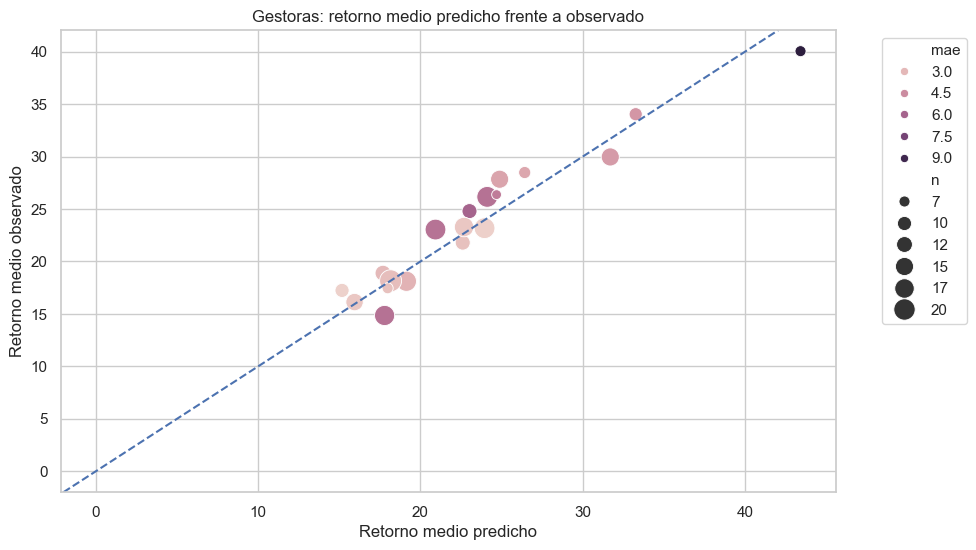

In [253]:
# ============================================================
# Análisis por gestor y AMC
# ============================================================

manager_table = group_error_table("fund_manager", min_n=3).head(20)
amc_table = group_error_table("amc", min_n=5).head(20)

display(manager_table)
display(amc_table)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=amc_table.reset_index(), x="mean_pred", y="mean_return", size="n", hue="mae", sizes=(50, 250))
plt.axline((0, 0), slope=1, linestyle="--")
plt.title("Gestoras: retorno medio predicho frente a observado")
plt.xlabel("Retorno medio predicho")
plt.ylabel("Retorno medio observado")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


> El gráfico compara el retorno medio observado y el retorno medio predicho para cada gestora (*AMC*). Las entidades situadas cerca de la diagonal presentan una correspondencia relativamente buena entre predicción y resultado observado, mientras que las desviaciones respecto a la línea indican sesgos sistemáticos de sobrepredicción o infrapredicción.

> Se observa que la mayoría de gestoras se concentran relativamente próximas a la diagonal, aunque algunas presentan errores medios absolutos más elevados y desviaciones más visibles. Las diferencias son especialmente relevantes en gestoras con retornos medios altos, donde la dispersión de resultados también es mayor.

> El tamaño de los puntos refleja el número de fondos por gestora y el color representa el MAE. Esto permite identificar casos donde errores elevados podrían estar asociados tanto a una mayor complejidad predictiva como a tamaños muestrales reducidos.

> Desde la perspectiva del problema principal-agente, el gráfico no demuestra habilidad real de gestión ni causalidad económica, pero sí permite detectar entidades donde el comportamiento observado difiere sistemáticamente de lo esperado por el modelo y que, por tanto, podrían requerir una revisión cualitativa adicional.


,return_1m,return_3y,nav,category_Equity,risk_score,log_aum,log_minimum_investment,valueresearch_rating
amc,,,,,,,,
aditya birla sun life mutual fund,0.953413,-1.660063,-3.704305,0.152606,0.171022,0.163665,-0.039536,-0.022517
axis mutual fund,-0.999901,-8.591270,2.332466,0.151466,-0.020867,-0.191009,0.057779,0.041763
bandhan mutual fund,-2.880312,-1.234712,1.288704,0.280148,-0.218946,0.138018,-0.028028,-0.053932
canara robeco mutual fund,-9.469772,-6.473414,1.825489,-0.139423,-0.300202,0.003203,0.065888,-0.022368
dsp mutual fund,6.700453,-1.892419,4.098113,0.669432,0.078259,-0.224854,-0.084112,0.058225


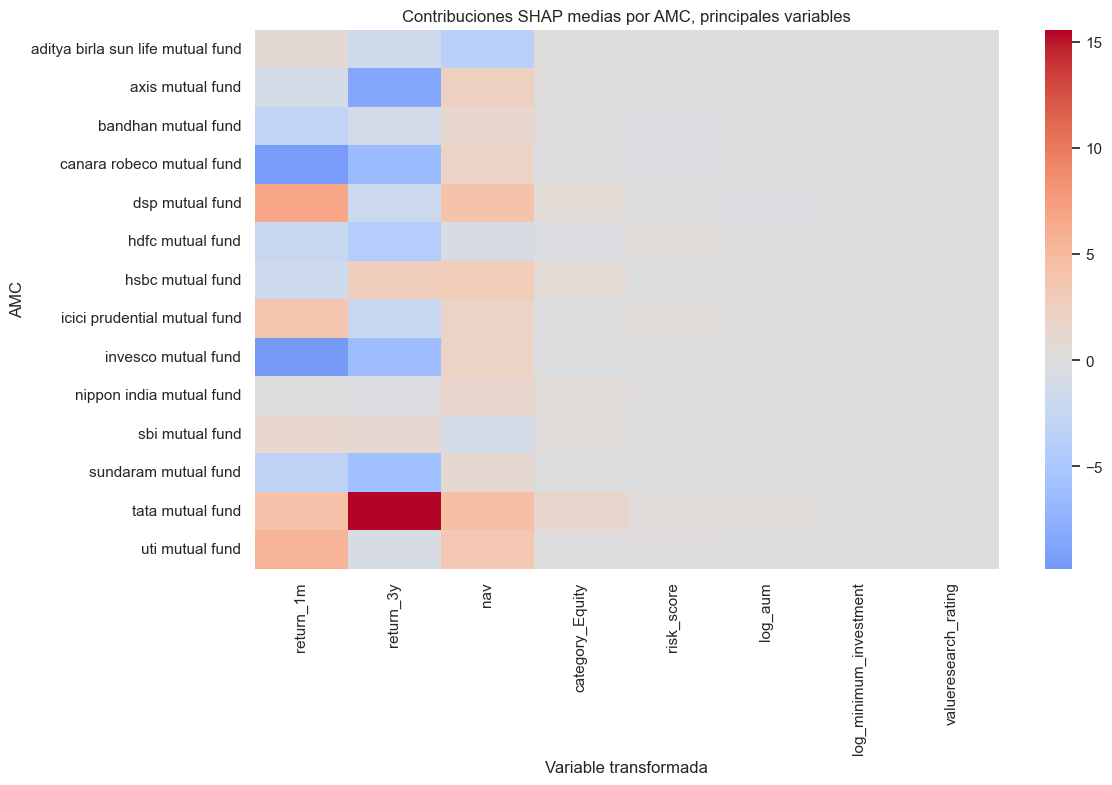

In [259]:
# SHAP agregado por grupos, cuando está disponible.
if shap_available:
    shap_full_test_sample = shap_test_sample.copy()
    shap_contrib_df = pd.DataFrame(shap_values_reg.values, columns=shap_test_sample.columns, index=shap_test_sample.index)
    top_shap_cols = shap_contrib_df.abs().mean().sort_values(ascending=False).head(8).index.tolist()

    shap_group_base = df.loc[shap_contrib_df.index, ["amc", "fund_manager", "category", "risk"]].copy()
    shap_group = pd.concat([shap_group_base, shap_contrib_df[top_shap_cols]], axis=1)

    amc_shap_summary = shap_group.groupby("amc")[top_shap_cols].mean()
    amc_counts = shap_group.groupby("amc").size()
    amc_shap_summary = amc_shap_summary.loc[amc_counts[amc_counts >= 3].index]

    display(amc_shap_summary.head())

    plt.figure(figsize=(12, 7))
    sns.heatmap(amc_shap_summary.head(15), center=0, cmap="coolwarm")
    plt.title("Contribuciones SHAP medias por AMC, principales variables")
    plt.xlabel("Variable transformada")
    plt.ylabel("AMC")
    plt.show()


> El *heatmap* muestra cómo varían las contribuciones SHAP medias de las principales variables entre distintas gestoras (*AMC*). Las mayores diferencias aparecen en `return_1m`, `return_3y` y `nav`, lo que indica que las predicciones del modelo para cada gestora dependen principalmente de la exposición de sus fondos a patrones de rendimiento histórico y características asociadas al NAV.

> Algunas gestoras presentan contribuciones positivas elevadas en retornos recientes o NAV, mientras que otras muestran contribuciones negativas persistentes, especialmente en `return_3y`. Por ejemplo, `dsp mutual fund` combina contribuciones positivas relevantes en `return_1m` y `nav`, mientras que `axis mutual fund` o `canara robeco mutual fund` presentan efectos negativos más intensos en variables de retorno histórico.

> Las variables estructurales como `risk_score`, `log_aum` o ratings muestran diferencias mucho menores entre gestoras, lo que sugiere que el modelo distingue principalmente perfiles de desempeño histórico más que características institucionales estables.

> Desde la perspectiva principal-agente, el gráfico resulta útil para separar el efecto de la composición observable de las carteras (riesgo, categoría o retornos previos) de una supuesta "habilidad gestora" implícita. En consecuencia, predicciones elevadas asociadas a determinadas gestoras no deben interpretarse automáticamente como evidencia de mejor calidad de gestión, sino como reflejo de las características predominantes de los fondos incluidos en la muestra.


### 4.12 "Fairness" básica como auditoría segmentada

En este contexto, `fairness` no se refiere a atributos personales protegidos, sino a una auditoría de comportamiento por grupos financieros: categoría, riesgo, gestora o gestor. La pregunta relevante es si el modelo asigna errores, probabilidades o predicciones de forma sistemáticamente desigual entre segmentos.

Esta auditoría no implica discriminación jurídica en sentido estricto. Su utilidad es detectar sesgos de modelo, concentración de errores y posibles incentivos distorsionados en la recomendación algorítmica de fondos.


Auditoría segmentada por category


,n,observed_top_rate,mean_predicted_top_probability,mae_return,mean_residual
category,,,,,
Equity,111,0.594595,0.687477,6.396232,0.454766
Other,98,0.193878,0.253232,4.136516,-0.406383
Hybrid,42,0.047619,0.116634,2.412968,0.289466
Debt,98,0.000000,0.015593,0.303241,-0.064611



Auditoría segmentada por risk


,n,observed_top_rate,mean_predicted_top_probability,mae_return,mean_residual
risk,,,,,
High,37,0.594595,0.603183,4.317539,0.788557
Very High,127,0.314961,0.418579,6.704107,0.095106
Moderately High,31,0.290323,0.304269,2.864692,0.737815
Moderate,85,0.129412,0.202930,1.315039,-0.351280
Low,30,0.166667,0.153969,0.805352,-0.516352
Low to Moderate,38,0.000000,0.015902,0.275744,-0.059716



Auditoría segmentada por amc


,n,observed_top_rate,mean_predicted_top_probability,mae_return,mean_residual
amc,,,,,
quant mutual fund,7,0.714286,0.710976,9.564136,-3.371572
tata mutual fund,9,0.555556,0.577063,4.108551,0.774669
icici prudential mutual fund,15,0.400000,0.467866,3.942519,-1.732882
motilal oswal mutual fund,8,0.375000,0.408981,3.544598,2.055243
edelweiss mutual fund,7,0.285714,0.405305,1.623249,-0.764247
union mutual fund,6,0.333333,0.383449,5.075762,1.681902
hdfc mutual fund,19,0.315789,0.346787,5.412173,2.043365
canara robeco mutual fund,11,0.363636,0.344013,2.693623,-0.809568
sbi mutual fund,19,0.210526,0.343766,2.238429,-0.777128


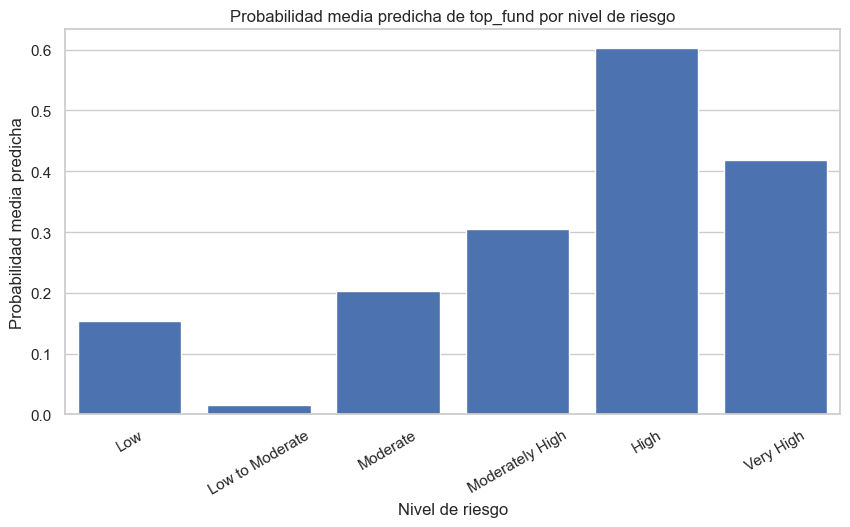

In [278]:
# ============================================================
# Auditoría segmentada sencilla
# ============================================================

fairness_tables = {}
for group_col, min_n in [("category", 3), ("risk", 3), ("amc", 5)]:
    table = (
        test_analysis.groupby(group_col)
        .agg(
            n=("fund_name", "count"),
            observed_top_rate=("top_fund", "mean"),
            mean_predicted_top_probability=("pred_top_proba", "mean"),
            mae_return=("abs_error", "mean"),
            mean_residual=("residual", "mean"),
        )
        .query("n >= @min_n")
        .sort_values("mean_predicted_top_probability", ascending=False)
    )
    fairness_tables[group_col] = table
    print(f"\nAuditoría segmentada por {group_col}")
    display(table.head(20))

plt.figure(figsize=(10, 5))
sns.barplot(data=fairness_tables["risk"].reset_index(), x="risk", y="mean_predicted_top_probability", order=risk_order_list, saturation=1, color="C0")
plt.title("Probabilidad media predicha de top_fund por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Probabilidad media predicha")
plt.xticks(rotation=30)
plt.show()


> La auditoría segmentada por riesgo muestra si la probabilidad predicha de `top_fund` aumenta con el perfil de riesgo. En la ejecución con el dataset, `High` y `Very High` concentran probabilidades medias más elevadas que los niveles de riesgo bajo o moderado. Esto no es necesariamente un sesgo indebido, pero sí evidencia que el modelo puede premiar exposición al riesgo; una decisión financiera responsable exigiría complementar el análisis con retorno ajustado al riesgo.

## 6. Conclusiones

El análisis confirma que la XAI aporta valor al problema principal-agente en gestión de inversiones porque transforma un modelo predictivo en un objeto más auditable. La importancia de variables, SHAP, LIME, PDP, ICE, ALE y los árboles sustitutos permiten examinar qué señales influyen en las predicciones, cómo varían los efectos entre fondos y qué segmentos presentan mayor error. Esta información puede reducir parte de la asimetría informativa entre inversor y agente, especialmente cuando el modelo se utiliza para preselección de fondos, revisión de gestores o control interno.

El hallazgo más relevante es que las variables de desempeño histórico suelen dominar las predicciones, en particular retornos previos de corto y medio plazo cuando están incluidos como predictores. Este resultado mejora la capacidad predictiva, pero también obliga a una lectura prudente: el modelo puede estar capturando persistencia, momentum o condiciones recientes de mercado, no necesariamente habilidad gestora persistente. La relación entre riesgo y retorno también exige cautela. Si los fondos de mayor riesgo aparecen con mayor probabilidad de pertenecer al grupo de mejor desempeño, la explicación no debe interpretarse como una recomendación automática de asumir más riesgo, sino como una señal que debe complementarse con métricas de retorno ajustado al riesgo, idoneidad del inversor y restricciones regulatorias.

Las limitaciones principales son metodológicas y financieras. Los modelos estiman asociaciones predictivas, no efectos causales. La correlación entre variables puede alterar las atribuciones de SHAP, LIME y permutation importance. El dataset no incorpora comisiones, benchmarks, flujos netos, holdings, rotación de cartera, factores de estilo ni una dimensión temporal completa. Además, al tratarse de fondos indios, las conclusiones no son directamente extrapolables a otros mercados sin validación externa. La extensión natural del trabajo consistiría en incorporar series temporales de NAV, métricas ajustadas al riesgo, variables textuales procedentes de documentación de fondos y una comparación entre mercados con diferentes regímenes regulatorios.

### 6.1 Discusión: XAI, finanzas delegadas y gobernanza algorítmica

Los resultados del notebook deben interpretarse desde una perspectiva de gobernanza. En un entorno principal-agente, un modelo predictivo puede reducir asimetrías informativas si ayuda al inversor a entender qué señales justifican una recomendación. Sin embargo, también puede crear una nueva capa de opacidad si sus predicciones se aceptan sin explicación suficiente.

La XAI contribuye a la gobernanza financiera de cuatro maneras. \1
1. **Transparencia funcional**: identifica variables dominantes en la predicción.
2. **Auditabilidad**: permite examinar errores por categoría, riesgo, gestora y gestor.
3. **Control de incentivos**: revela si el modelo premia mecánicamente riesgo alto o tamaño del fondo.
4. **Trazabilidad local**: explica casos individuales, útil para revisión interna o comunicación con inversores.

No obstante, la XAI no resuelve por sí sola problemas estructurales de causalidad. Una explicación SHAP alta para una variable no demuestra que modificar esa variable cause mayor retorno. En presencia de variables correlacionadas, las atribuciones pueden ser inestables o repartirse de forma arbitraria entre predictores sustitutos.

### 6.2 Limitaciones metodológicas

El análisis presenta varias limitaciones relevantes. \1
- **Correlación frente a causalidad**: los modelos identifican patrones predictivos, no efectos causales.
- **Sesgo de supervivencia**: si el dataset sólo contiene fondos activos, los fondos cerrados o fusionados podrían estar ausentes.
- **Solapamiento temporal**: los retornos históricos pueden compartir información con el retorno objetivo.
- **Variables omitidas**: comisiones, benchmark, tracking error, rotación, flujos netos, holdings y estilo factorial no están incorporados.
- **Atribución bajo correlación**: SHAP, LIME y permutation importance pueden asignar importancia de forma inestable cuando las variables están correlacionadas.
- **Interpretabilidad local frágil**: las explicaciones de un único fondo pueden depender de pequeñas perturbaciones del modelo o de la muestra.
- **Riesgo de racionalización ex post**: una explicación visual convincente no debe confundirse con una justificación económica completa.

### 6.2 Conclusiones analíticas

A partir del análisis ejecutado sobre el dataset, las conclusiones principales son las siguientes.

#### ¿Qué variables dominan las predicciones?

Las variables de desempeño histórico dominan claramente el comportamiento predictivo del modelo. Tanto SHAP como *Permutation Importance*, los *dependence plots* y el *surrogate tree* identifican `return_1m`, `return_3y` y `nav` como las señales más influyentes. Variables como `risk_score`, `log_aum` y la pertenencia a la categoría Equity presentan un papel secundario y más heterogéneo. Los resultados sugieren que el modelo captura principalmente patrones de persistencia y momentum en los retornos históricos, más que características estructurales estables asociadas a la gestora o al gestor.


#### ¿El modelo favorece implícitamente perfiles de riesgo altos?

Parcialmente. Los segmentos `High` y `Very High` presentan mayores retornos medios observados y mayores probabilidades medias predichas de pertenecer al grupo `top_fund`. Sin embargo, los PDP, ICE y ALE muestran que el efecto de `risk_score` no es lineal ni monotónico: los niveles intermedios de riesgo pueden reducir la predicción mientras que determinados niveles altos generan contribuciones positivas. Por tanto, el modelo no favorece mecánicamente un mayor riesgo, aunque sí parece asociar ciertos perfiles de riesgo elevado con retornos potencialmente más altos dentro de la muestra analizada.


#### ¿Qué diferencias aparecen entre importancia global y local?

Las explicaciones globales muestran que los retornos históricos y el NAV concentran gran parte de la importancia promedio del modelo. Sin embargo, las explicaciones locales revelan una heterogeneidad considerable entre fondos individuales. Los *waterfall plots*, LIME y los contrafactuales muestran casos donde variables secundarias globalmente (como `log_aum`, la categoría Equity o determinados gestores) adquieren una influencia decisiva en observaciones concretas. Esto confirma que la lógica predictiva local puede diferir significativamente del comportamiento agregado del modelo.


#### ¿Qué riesgos de opacidad aparecen en asset management?

El principal riesgo consiste en interpretar las predicciones del modelo como evidencia de habilidad gestora cuando gran parte de la capacidad predictiva proviene de variables observables relacionadas con retornos históricos, categoría o exposición al riesgo. Además, algunas variables aparentemente interpretables (como `nav` o determinados identificadores de gestora) muestran relaciones complejas y parcialmente opacas, difíciles de justificar económicamente de forma directa. Esto refuerza la necesidad de complementar las explicaciones algorítmicas con supervisión financiera y análisis cualitativo adicional.


#### ¿Qué limitaciones tienen SHAP y LIME con variables correlacionadas?

SHAP, LIME y *Permutation Importance* pueden redistribuir importancia entre variables correlacionadas de forma potencialmente inestable. En este dataset, las variables de retornos históricos presentan correlaciones relevantes, lo que puede alterar la asignación relativa de importancia entre `return_1m`, `return_3y` y otras señales relacionadas. Las diferencias observadas entre SHAP, LIME, PDP e ICE muestran además que distintas técnicas pueden enfatizar aspectos distintos del comportamiento del modelo. Por ello, las explicaciones deben interpretarse como descripciones del mecanismo predictivo y no como evidencia causal sobre el rendimiento financiero.


#### ¿Hasta qué punto XAI mejora la interpretación del problema principal-agente?

Las técnicas XAI mejoran significativamente la auditabilidad del modelo porque permiten identificar qué variables dominan las predicciones, cómo cambian sus efectos entre segmentos y qué factores explican decisiones individuales concretas. El análisis segmentado, los gráficos SHAP y las explicaciones locales permiten detectar sesgos, heterogeneidad y regiones donde el modelo resulta menos fiable, especialmente en fondos Equity y perfiles de riesgo elevados.

No obstante, la explicabilidad no elimina la asimetría informativa inherente al problema principal-agente ni demuestra habilidad gestora real. Su principal aportación consiste en hacer más transparentes los supuestos y dependencias internas del modelo predictivo utilizado en contextos de inversión delegada.

## 7. Referencias

* Aas, K., et al. (2021). Explaining individual predictions when features are dependent: More accurate approximations to Shapley values. *Artificial Intelligence, 298*, 103502. https://arxiv.org/abs/1903.10464

* Tantrik, A. (s. f.). *Mutual fund NAV data* [Data set]. Kaggle. https://www.kaggle.com/datasets/aloktantrik/mutual-fund-nav-data

* Arrieta, A. B., et al. (2020). Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI. *Information Fusion, 58*. https://www.sciencedirect.com/science/article/abs/pii/S1566253519308103 

* Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*. https://dl.acm.org/doi/10.1145/2939672.2939785

* Jensen, M. C., & Meckling, W. H. (1976). Theory of the firm: Managerial behavior, agency costs and ownership structure. *Journal of Financial Economics, 3*(4), 305–360. https://www.sciencedirect.com/science/article/pii/0304405X7690026X

* Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems, 30*. https://arxiv.org/abs/1705.07874

* Molnar, C. (2022). *Interpretable Machine Learning* (2nd ed.). https://christophm.github.io/interpretable-ml-book/

* Ribeiro, M. T. et al. (2016). “Why should I trust you?” Explaining the predictions of any classifier. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*. https://dl.acm.org/doi/10.1145/2939672.2939778

* Ross, S. A. (1973). The economic theory of agency: The principal’s problem. *The American Economic Review, 63*(2), 134–139. https://www.jstor.org/stable/1817064

* Shapley, L. S. (1953). A value for n-person games. En H. W. Kuhn & A. W. Tucker (Eds.), *Contributions to the Theory of Games II* (pp. 307–317). Princeton University Press.
